# Hospital Resource Allocation | Reinforcement Learning
### CISC 856 · Group 8 · Queen's University
Mirna Imbabi · Salma ElSherif · Norhan Mahmoud · Nehal Hamada

---

## Overview

This notebook models hospital triage as an MDP and trains PPO, DQN, and A2C agents (Stable Baselines 3) on a custom Gymnasium environment to allocate ICU beds, ward beds, ventilators, and staff to incoming patients under Poisson arrivals.

**Research questions:**
1. Which algorithm best learns the allocation policy?
2. How does the policy degrade under patient surge?
3. Does reward shaping (queue penalties) change policy behaviour?
4. How sensitive is performance to capacity and network architecture?
5. Does explicit mortality signalling change policy behaviour? 
6. Does an explicit overflow penalty help under surge? 
7. Does training A2C on parallel environments fix its collapse? 
8. Is the flat λ=6.0 result a real policy limit or a capacity ceiling? 
9. Does tuning DQN move it the way tuning didn't move PPO? 

---

## MDP Formulation

**State** $s \in \mathbb{R}^9$ (Groups A–F, I–K) / $\mathbb{R}^{10}$ (Group G):
$s = [b_{\text{ICU}},\; b_{\text{ward}},\; v,\; f,\; q_{\text{crit}},\; q_{\text{mod}},\; q_{\text{stab}},\; o_{\text{ward}},\; h]$ (+ $w_{\text{crit}}$ in Group G)

| Symbol | Meaning | Range |
|--------|---------|-------|
| $b_{\text{ICU}}$ | Available ICU beds | $[0, 10]$ |
| $b_{\text{ward}}$ | Available ward beds | $[0, 30]$ |
| $v$ | Available ventilators | $[0, 5]$ |
| $f$ | Active staff shifts | $[0, 5]$ |
| $q_{\text{crit}}, q_{\text{mod}}, q_{\text{stab}}$ | Patient queues by acuity | $[0, 20]$ each |
| $o_{\text{ward}}$ | Ward occupancy | $[0, 30]$ |
| $h$ | Hour of day | $[0, 23]$ |
| $w_{\text{crit}}$ | Max wait among queued critical patients (Group G only) | $[0, 6]$ |

**Actions** $\mathcal{A} = \{0,1,2,3\}$: 0 admit ICU (ventilator w.p. 0.60), 1 admit ward, 2 redirect externally, 3 call extra staff shift.

**Reward:**
$$r_t = r_{\text{action}} + 0.5 \cdot n_{\text{xfer}} - w_c \frac{q_{\text{crit}}}{Q_{\max}} - w_m \frac{q_{\text{mod}}}{Q_{\max}} - w_s \frac{q_{\text{stab}}}{Q_{\max}} - 0.5 \cdot \mathbb{1}[\text{invalid}]$$

where $r_{\text{action}} \in \{+5, +3, +1, 0\}$ for ICU/ward/redirect/staff, and `standard` mode uses $w_c=3.0,\; w_m=1.0,\; w_s=0.5$.

---



In [ ]:
#  Imports & folder setup

import os, sys, glob, copy, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env

from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
import stable_baselines3

warnings.filterwarnings("ignore", category=UserWarning)

# All outputs go here — models, figures, TensorBoard logs
OUT     = Path("output")
MODELS  = OUT / "models"
FIGURES = OUT / "figures"
TB_LOGS = OUT / "tb_logs"

for d in [MODELS, FIGURES, TB_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Python            : {sys.version.split()[0]}")
print(f"stable-baselines3 : {stable_baselines3.__version__}")
print(f"gymnasium         : {gym.__version__}")


Python            : 3.11.0
stable-baselines3 : 2.8.0
gymnasium         : 1.2.3


In [ ]:
#  HospitalEnv : our custom Gymnasium environment


class HospitalEnv(gym.Env):
    """
    Hospital triage MDP — 4 discrete actions, 9-dim (default) or 10-dim (Group G) obs.

    Actions
    -------
    0  Admit to ICU     — needs a ventilator with probability P_VENT
    1  Admit to ward    — staff-gated; critical patients always need ICU
    2  Redirect         — send the next patient to an external facility
    3  Call extra shift — opens more ward supervision capacity (up to MAX_EXTRA_SHIFTS)

    Observation  (wait_time_aware=False, default)
    -----------  [b_icu, b_ward, v, f, q_crit, q_mod, q_stab, o_ward, hour]

    Observation  (wait_time_aware=True, Group G)
    -----------  [b_icu, b_ward, v, f, q_crit, q_mod, q_stab, o_ward, hour, max_wait_crit]
    """
    metadata = {"render_modes": []}

    #  Class-level constants
    P_VENT           = 0.60   # fraction of ICU admits needing a ventilator
    P_STEPDOWN       = 0.10   # per-step probability an ICU patient steps down to ward
    P_DISCHARGE_WARD = 0.05   # per-step probability a ward patient is discharged (geometric LOS, mean ~20 steps)
    STAFF_PER_SHIFT  = 5      # ward patients one shift can supervise
    Q_MAX            = 20     # hard cap on each queue (overflow is lost)
    MAX_EXTRA_SHIFTS = 2      # shifts callable beyond the base complement
    EPISODE_LEN      = 200    # timesteps per episode

    def __init__(
        self,
        arrival_rate:        float = 3.0,
        max_icu_beds:        int   = 10,
        max_ward_beds:       int   = 30,
        max_vents:           int   = 5,
        max_staff:           int   = 3,
        reward_mode:         str   = "standard",
        reduced_cap:         bool  = False,
        high_cap:            bool  = False,
        wait_time_aware:     bool  = False,  # Group G: track per-patient wait times
        max_wait_crit_steps: int   = 6,      # Group G: steps before critical mortality
        overflow_penalty:    float = 0.0,    # Group H: severity-weighted penalty per lost patient
        idle_ward_penalty:   float = 0.0,    # Group L1: penalty for an idle ward bed while mod/stab queue is non-empty
        overflow_blend:      float = 0.0,    # Group L2: gamma in [0,1], trades w_c off against overflow_penalty instead of stacking them
        mortality_penalty:   float = 2.0,    # Group L3: per-death penalty (Group G used a fixed 2.0; now tunable)
        w_c_override:        float = None,   # Group L4: custom queue weights for a weight-sweep, bypasses reward_mode presets
        w_m_override:        float = None,
        w_s_override:        float = None,
    ):
        super().__init__()
        self.arrival_rate        = arrival_rate
        self.reward_mode         = reward_mode
        self.wait_time_aware     = wait_time_aware
        self.max_wait_crit_steps = max_wait_crit_steps
        self.overflow_penalty    = overflow_penalty
        self.idle_ward_penalty   = idle_ward_penalty
        self.overflow_blend      = overflow_blend
        self.mortality_penalty   = mortality_penalty
        self.w_c_override        = w_c_override
        self.w_m_override        = w_m_override
        self.w_s_override        = w_s_override

        # Capacity overrides for Group D stress-test experiments
        if reduced_cap:
            self.MAX_ICU = 5;  self.MAX_VENT = 2
        elif high_cap:
            self.MAX_ICU = 15; self.MAX_VENT = 8
        else:
            self.MAX_ICU = max_icu_beds; self.MAX_VENT = max_vents

        self.MAX_WARD   = max_ward_beds
        self.BASE_STAFF = max_staff
        self.MAX_STAFF  = max_staff + self.MAX_EXTRA_SHIFTS

        # Group G adds a 10th obs dim: max wait among queued critical patients
        obs_high_list = [
            self.MAX_ICU, self.MAX_WARD, self.MAX_VENT, self.MAX_STAFF,
            self.Q_MAX, self.Q_MAX, self.Q_MAX, self.MAX_WARD, 23,
        ]
        if wait_time_aware:
            obs_high_list.append(float(max_wait_crit_steps))
        obs_high = np.array(obs_high_list, dtype=np.float32)

        self.observation_space = spaces.Box(
            low=np.zeros(len(obs_high_list), dtype=np.float32),
            high=obs_high,
            dtype=np.float32,
        )
        self.action_space = spaces.Discrete(4)

    #  Private helpers

    def _ward_cap(self) -> int:
        """Max additional ward admits right now (physical beds AND staff headroom)."""
        return max(0, min(self.b_ward, self.f * self.STAFF_PER_SHIFT - self.o_ward))

    def _obs(self) -> np.ndarray:
        base = np.array([
            self.b_icu, self.b_ward, self.v, self.f,
            self.q["crit"], self.q["mod"], self.q["stab"],
            self.o_ward, self.hour,
        ], dtype=np.float32)
        if self.wait_time_aware:
            max_w = float(max(self.wait["crit"])) if self.wait["crit"] else 0.0
            max_w = min(max_w, float(self.max_wait_crit_steps))  # cap at threshold
            return np.append(base, max_w)
        return base

    def _next_patient(self, exclude_critical: bool = False):
        """Return the highest-priority non-empty queue label, or None."""
        if not exclude_critical and self.q["crit"] > 0: return "crit"
        if self.q["mod"]  > 0: return "mod"
        if self.q["stab"] > 0: return "stab"
        return None

    #  Gymnasium interface

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.b_icu      = self.MAX_ICU
        self.b_ward     = self.MAX_WARD
        self.v          = self.MAX_VENT
        self.f          = self.BASE_STAFF
        self.o_ward     = 0
        self.o_icu      = 0
        self.o_icu_vent = 0   # tracks ventilated ICU patients for accurate step-down vent returns
        self.q          = {"crit": 0, "mod": 0, "stab": 0}
        self.hour       = 8
        self.t          = 0
        self.total_deaths = 0
        if self.wait_time_aware:
            # Per-patient FIFO wait-time lists (0 = just arrived)
            self.wait = {"crit": [], "mod": [], "stab": []}
        return self._obs(), {}

    def step(self, action: int):
        n_xfer = n_admitted = n_redirected = 0
        n_died = 0
        invalid = False

#  1. New patients arrive
        total = self.np_random.poisson(self.arrival_rate)
        crit  = self.np_random.binomial(total, 0.20)
        rem   = total - crit
        mod   = self.np_random.binomial(rem, 0.625)  # 0.625 × 0.80 ≈ 0.50 total
        stab  = rem - mod

        if self.wait_time_aware:
#  Group G: per-patient wait tracking
            n_overflow = {}
            for acuity, n in [("crit", crit), ("mod", mod), ("stab", stab)]:
                spaces_left = self.Q_MAX - len(self.wait[acuity])
                to_add = max(0, min(n, spaces_left))
                n_overflow[acuity] = n - to_add          # patients lost to overflow
                self.wait[acuity].extend([0] * to_add)
# Mortality check BEFORE incrementing, new arrivals still have wait=0
            survivors = [w for w in self.wait["crit"]
                         if w < self.max_wait_crit_steps]
            n_died = len(self.wait["crit"]) - len(survivors)
            self.wait["crit"] = survivors
            self.total_deaths += n_died
            # Advancing all clocks (after deaths are removed)
            for acuity in ("crit", "mod", "stab"):
                self.wait[acuity] = [w + 1 for w in self.wait[acuity]]
            # Keep integer q counts in sync (used by _next_patient and reward)
            for k in ("crit", "mod", "stab"):
                self.q[k] = len(self.wait[k])
        else:
            # Track overflow: patients lost because queue hit Q_MAX
            n_overflow = {}
            for k, n in [("crit", crit), ("mod", mod), ("stab", stab)]:
                n_overflow[k] = max(0, self.q[k] + n - self.Q_MAX)  # patients lost
                self.q[k]     = min(self.Q_MAX, self.q[k] + n)

#  2. Ward discharges
        if self.o_ward > 0:
            discharged  = self.np_random.binomial(self.o_ward, self.P_DISCHARGE_WARD)
            self.o_ward -= discharged
            self.b_ward += discharged

#  3. ICU → ward step-downs
        if self.o_icu > 0:
            possible = self.np_random.binomial(self.o_icu, self.P_STEPDOWN)
            actual   = min(possible, self._ward_cap())
            if actual > 0:
                vents_back = int(self.np_random.hypergeometric(
                    self.o_icu_vent,
                    max(0, self.o_icu - self.o_icu_vent),
                    actual,
                )) if self.o_icu_vent > 0 else 0

                self.o_icu      -= actual
                self.o_icu_vent -= vents_back
                self.b_icu      += actual
                self.v           = min(self.v + vents_back, self.MAX_VENT)
                self.o_ward     += actual
                self.b_ward     -= actual
                n_xfer           = actual

        #  4. Execute agent action
        if action == 0:   # Admit to ICU
            patient = self._next_patient()
            if patient and self.b_icu > 0:
                needs_vent = self.np_random.random() < self.P_VENT
                if needs_vent and self.v == 0:
                    invalid = True
                else:
                    self.q[patient] -= 1
                    if self.wait_time_aware:
                        self.wait[patient].pop(0)  # FIFO: longest-waiting first
                    self.b_icu -= 1
                    self.o_icu += 1
                    if needs_vent:
                        self.v -= 1
                        self.o_icu_vent += 1
                    n_admitted = 1
            else:
                invalid = True

        elif action == 1:  # Admit to ward
            patient = self._next_patient(exclude_critical=True)
            if patient and self._ward_cap() > 0:
                self.q[patient] -= 1
                if self.wait_time_aware:
                    self.wait[patient].pop(0)
                self.b_ward -= 1
                self.o_ward += 1
                n_admitted = 1
            else:
                invalid = True

        elif action == 2:  # Redirect
            patient = self._next_patient()
            if patient:
                self.q[patient] -= 1
                if self.wait_time_aware:
                    self.wait[patient].pop(0)
                n_redirected = 1
            else:
                invalid = True

        elif action == 3:  # Call extra staff shift
            if self.f < self.MAX_STAFF:
                self.f += 1
            else:
                invalid = True

        #  5. Compute reward
        icu_bonus   = 5.0 if (action == 0 and n_admitted == 1)   else 0.0
        ward_bonus  = 3.0 if (action == 1 and n_admitted == 1)   else 0.0
        redir_bonus = 1.0 if (action == 2 and n_redirected == 1) else 0.0

        if self.reward_mode == "standard":
            w_c, w_m, w_s, xb = 3.0, 1.0, 0.5, 0.5
        elif self.reward_mode == "equal_penalty":
            w_c, w_m, w_s, xb = 2.0, 2.0, 0.5, 0.5
        elif self.reward_mode == "no_penalty":
            w_c, w_m, w_s, xb = 0.0, 0.0, 0.0, 0.5
        elif self.reward_mode == "throughput_only":
            w_c, w_m, w_s, xb = 0.0, 0.0, 0.0, 0.0
        else:
            raise ValueError(
                f"Unknown reward_mode {self.reward_mode!r}. "
                "Valid choices: 'standard', 'equal_penalty', 'no_penalty', 'throughput_only'."
            )

        # Group L4: weight-sweep override, bypasses the reward_mode presets above
        if self.w_c_override is not None: w_c = self.w_c_override
        if self.w_m_override is not None: w_m = self.w_m_override
        if self.w_s_override is not None: w_s = self.w_s_override

        ''' Group L2: blend overflow penalty against the queue penalty instead of stacking them.
         gamma=0 reproduces Group H exactly. gamma>0 shifts weight from the per-step queue
         penalty onto the one-time overflow cost, so a patient who eventually overflows
         isn't charged twice for the same failure.'''

        gamma = self.overflow_blend
        w_c_eff = w_c * (1.0 - gamma)
        effective_overflow_penalty = self.overflow_penalty + gamma * w_c if gamma > 0 else self.overflow_penalty

        overflow_pen = effective_overflow_penalty * (
            2.0 * n_overflow.get("crit", 0) +
            1.0 * n_overflow.get("mod",  0) +
            0.5 * n_overflow.get("stab", 0)
        )

        '''Group L1: penalize an idle ward bed while a treatable (mod/stab) patient is queued.
         Targets the "always admit to ICU" collapse directly instead of relying on the
         queue penalty to discourage it indirectly.'''
        idle_ward_pen = self.idle_ward_penalty if (
            self.b_ward > 0 and (self.q["mod"] + self.q["stab"]) > 0
        ) else 0.0

        reward = float(
            icu_bonus + ward_bonus + redir_bonus
            + xb * n_xfer
            - w_c_eff * (self.q["crit"] / self.Q_MAX)
            - w_m * (self.q["mod"]  / self.Q_MAX)
            - w_s * (self.q["stab"] / self.Q_MAX)
            - (0.5 if invalid else 0.0)
            - (self.mortality_penalty * n_died if self.wait_time_aware else 0.0)  # Group L3: tunable mortality penalty
            - overflow_pen     # Group H/L2 overflow penalty
            - idle_ward_pen    # Group L1 idle-ward penalty
        )

        self.hour = (self.hour + 1) % 24
        self.t   += 1
        done = self.t >= self.EPISODE_LEN

        return self._obs(), reward, done, False, {
            "n_treat":      n_admitted + n_redirected,
            "n_admitted":   n_admitted,
            "n_redirected": n_redirected,
            "n_xfer":       n_xfer,
            "invalid":      invalid,
            "q_crit":       self.q["crit"],
            "n_died":          n_died,                        # deaths this step (0 if not wait_time_aware)
            "total_deaths":    self.total_deaths,              # cumulative deaths this episode
            "n_overflow":      sum(n_overflow.values()),       # Group H: patients lost to overflow
            "n_overflow_crit": n_overflow.get("crit", 0),      # critical-only overflow count
        }


---

## Environment Validation

Sanity check that `HospitalEnv` passes Gymnasium's `check_env`, and a random-policy floor to confirm the environment rewards sensible behaviour.

In [ ]:
#  Sanity check + random policy floor

env_test = HospitalEnv()
check_env(env_test, warn=True)
print("Gymnasium API check passed")

obs, _ = env_test.reset(seed=0)
print(f"\nObservation shape : {obs.shape}")
print(f"Dimensions        : [b_icu, b_ward, v, f, q_crit, q_mod, q_stab, o_ward, hour]")
print(f"Initial state     : {obs}")
print(f"Action space      : {env_test.action_space}  (0=ICU admit, 1=ward admit, 2=redirect, 3=call staff)")

random_rewards = []
for seed in [0, 1, 2, 3, 4]:
    obs, _ = env_test.reset(seed=seed)
    ep_r = 0.0; done = False
    while not done:
        obs, r, done, _, _ = env_test.step(env_test.action_space.sample())
        ep_r += r
    random_rewards.append(ep_r)

print(f"\nRandom policy reward (5 seeds): {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")
print("(This should be clearly negative because random actions let queues pile up fast)")


Gymnasium API check passed

Observation shape : (9,)
Dimensions        : [b_icu, b_ward, v, f, q_crit, q_mod, q_stab, o_ward, hour]
Initial state     : [10. 30.  5.  3.  0.  0.  0.  0.  8.]
Action space      : Discrete(4)  (0=ICU admit, 1=ward admit, 2=redirect, 3=call staff)

Random policy reward (5 seeds): -164.0 ± 94.6
(This should be clearly negative because random actions let queues pile up fast)


In [ ]:
#  Greedy rule-based baseline

# DEFAULT_MAX_STAFF mirrors HospitalEnv's default config (max_staff=3 +
DEFAULT_MAX_STAFF = 3 + HospitalEnv.MAX_EXTRA_SHIFTS


def greedy_action(obs: np.ndarray) -> int:
    b_icu, b_ward, v, f, q_crit, q_mod, q_stab, o_ward, *_ = obs
    ward_slots = max(0, min(b_ward, f * HospitalEnv.STAFF_PER_SHIFT - o_ward))
    total_q    = q_crit + q_mod + q_stab

    if q_crit > 0 and b_icu > 0:                     return 0   # ICU admit — highest priority
    if (q_mod + q_stab) > 0 and ward_slots > 0:       return 1   # ward admit
    if total_q > 0 and ward_slots == 0 and f < DEFAULT_MAX_STAFF:
        return 3   # unblock ward by calling staff
    if total_q > 0:                                    return 2   # redirect — last resort
    return 3                                                       # nothing to do


def evaluate_greedy(arrival_rate=3.0, n_episodes=100, seed=99, **env_kwargs):
    env = HospitalEnv(arrival_rate=arrival_rate, **env_kwargs)
    rng = np.random.default_rng(seed)
    rewards, unserved, admitted_list, redirected_list, deaths_list = [], [], [], [], []

    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        ep_r = ep_u = ep_adm = ep_redir = ep_deaths = 0; done = False
        while not done:
            obs, r, done, _, info = env.step(greedy_action(obs))
            ep_r     += r
            ep_u     += info["q_crit"]
            ep_adm   += info["n_admitted"]
            ep_redir += info["n_redirected"]
            ep_deaths+= info.get("n_died", 0)   # 0 for non-time-aware envs
        rewards.append(ep_r)
        unserved.append(ep_u)
        admitted_list.append(ep_adm)
        redirected_list.append(ep_redir)
        deaths_list.append(ep_deaths)

    return dict(
        mean_reward      = float(np.mean(rewards)),
        std_reward       = float(np.std(rewards)),
        mean_unserved    = float(np.mean(unserved)),
        std_unserved     = float(np.std(unserved)),
        mean_admitted    = float(np.mean(admitted_list)),
        std_admitted     = float(np.std(admitted_list)),
        mean_redirected  = float(np.mean(redirected_list)),
        std_redirected   = float(np.std(redirected_list)),
        mean_deaths      = float(np.mean(deaths_list)),   # 0 for non-time-aware envs
        std_deaths       = float(np.std(deaths_list)),
    )


g = evaluate_greedy()
print("Greedy baseline (λ=3.0, 100 episodes):")
print(f"  Reward        : {g['mean_reward']:.2f} ± {g['std_reward']:.2f}")
print(f"  Admitted      : {g['mean_admitted']:.1f} ± {g['std_admitted']:.1f} patients/episode")
print(f"  Redirected    : {g['mean_redirected']:.1f} ± {g['std_redirected']:.1f} patients/episode")
print(f"  Crit unserved : {g['mean_unserved']:.1f} ± {g['std_unserved']:.1f} /episode")



Greedy baseline (λ=3.0, 100 episodes):
  Reward        : 499.57 ± 61.94
  Admitted      : 183.3 ± 8.3 patients/episode
  Redirected    : 1.9 ± 2.5 patients/episode
  Crit unserved : 363.7 ± 294.2 /episode


In [ ]:
#  Experiment Registry

from collections import Counter

EXPERIMENTS = {
    #  Group A : core algorithm comparison
    "A1": ("PPO", dict(arrival_rate=3.0), {}, "A", "A1 PPO baseline"),
    "A2": ("DQN", dict(arrival_rate=3.0), {}, "A", "A2 DQN baseline"),
    "A3": ("A2C", dict(arrival_rate=3.0), {}, "A", "A3 A2C baseline"),

    #  Group B : arrival-rate sweep
    "B1": ("PPO", dict(arrival_rate=1.5), {}, "B", "B1 PPO lam=1.5"),
    "B2": ("DQN", dict(arrival_rate=1.5), {}, "B", "B2 DQN lam=1.5"),
    "B3": ("A2C", dict(arrival_rate=1.5), {}, "B", "B3 A2C lam=1.5"),
    "B4": ("PPO", dict(arrival_rate=4.5), {}, "B", "B4 PPO lam=4.5"),
    "B5": ("DQN", dict(arrival_rate=4.5), {}, "B", "B5 DQN lam=4.5"),
    "B6": ("A2C", dict(arrival_rate=4.5), {}, "B", "B6 A2C lam=4.5"),
    "B7": ("PPO", dict(arrival_rate=6.0), {}, "B", "B7 PPO lam=6.0"),
    "B8": ("DQN", dict(arrival_rate=6.0), {}, "B", "B8 DQN lam=6.0"),
    "B9": ("A2C", dict(arrival_rate=6.0), {}, "B", "B9 A2C lam=6.0"),

    #  Group C : reward-shaping ablation
    "C1": ("PPO", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C1 PPO equal-pen"),
    "C2": ("DQN", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C2 DQN equal-pen"),
    "C3": ("A2C", dict(arrival_rate=3.0, reward_mode="equal_penalty"),   {}, "C", "C3 A2C equal-pen"),
    "C4": ("PPO", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C4 PPO no-pen"),
    "C5": ("DQN", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C5 DQN no-pen"),
    "C6": ("A2C", dict(arrival_rate=3.0, reward_mode="no_penalty"),      {}, "C", "C6 A2C no-pen"),
    "C7": ("PPO", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C7 PPO thrpt"),
    "C8": ("DQN", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C8 DQN thrpt"),
    "C9": ("A2C", dict(arrival_rate=3.0, reward_mode="throughput_only"), {}, "C", "C9 A2C thrpt"),

    #  Group D : capacity stress
    "D1": ("PPO", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D1 PPO reduced"),
    "D2": ("DQN", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D2 DQN reduced"),
    "D3": ("A2C", dict(arrival_rate=3.0, reduced_cap=True), {}, "D", "D3 A2C reduced"),
    "D4": ("PPO", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D4 PPO high-cap"),
    "D5": ("DQN", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D5 DQN high-cap"),
    "D6": ("A2C", dict(arrival_rate=3.0, high_cap=True),    {}, "D", "D6 A2C high-cap"),

#  Group E : PPO network architecture
    "E2": ("PPO", dict(arrival_rate=3.0), {"net_arch": [128, 128]}, "E", "E2 PPO 128x128"),
    "E3": ("PPO", dict(arrival_rate=3.0), {"net_arch": [256, 256]}, "E", "E3 PPO 256x256"),

#  Group F : PPO hyperparameter sensitivity
    "F1": ("PPO", dict(arrival_rate=3.0), {"learning_rate": 1e-3},  "F", "F1 PPO lr=1e-3"),
    "F2": ("PPO", dict(arrival_rate=3.0), {"learning_rate": 1e-4},  "F", "F2 PPO lr=1e-4"),
    "F3": ("PPO", dict(arrival_rate=3.0), {"n_steps": 512},         "F", "F3 PPO n=512"),
    "F4": ("PPO", dict(arrival_rate=3.0), {"n_steps": 2048},        "F", "F4 PPO n=2048"),

#  Replication runs : Groups A and B
    "A1f": ("PPO", dict(arrival_rate=3.0), {}, "A_fixed", "A1f PPO fixed-reward"),
    "A2f": ("DQN", dict(arrival_rate=3.0), {}, "A_fixed", "A2f DQN fixed-reward"),
    "A3f": ("A2C", dict(arrival_rate=3.0), {}, "A_fixed", "A3f A2C fixed-reward"),
    "B1f": ("PPO", dict(arrival_rate=1.5), {}, "B_fixed", "B1f PPO lam=1.5 fixed"),
    "B2f": ("DQN", dict(arrival_rate=1.5), {}, "B_fixed", "B2f DQN lam=1.5 fixed"),
    "B3f": ("A2C", dict(arrival_rate=1.5), {}, "B_fixed", "B3f A2C lam=1.5 fixed"),
    "B4f": ("PPO", dict(arrival_rate=4.5), {}, "B_fixed", "B4f PPO lam=4.5 fixed"),
    "B5f": ("DQN", dict(arrival_rate=4.5), {}, "B_fixed", "B5f DQN lam=4.5 fixed"),
    "B6f": ("A2C", dict(arrival_rate=4.5), {}, "B_fixed", "B6f A2C lam=4.5 fixed"),
    "B7f": ("PPO", dict(arrival_rate=6.0), {}, "B_fixed", "B7f PPO lam=6.0 fixed"),
    "B8f": ("DQN", dict(arrival_rate=6.0), {}, "B_fixed", "B8f DQN lam=6.0 fixed"),
    "B9f": ("A2C", dict(arrival_rate=6.0), {}, "B_fixed", "B9f A2C lam=6.0 fixed"),

#  Group G : time-aware reward + critical-patient mortality
    "G1": ("PPO", dict(arrival_rate=3.0, wait_time_aware=True, max_wait_crit_steps=6), {}, "G", "G1 PPO time-aware"),
    "G2": ("DQN", dict(arrival_rate=3.0, wait_time_aware=True, max_wait_crit_steps=6), {}, "G", "G2 DQN time-aware"),
    "G3": ("A2C", dict(arrival_rate=3.0, wait_time_aware=True, max_wait_crit_steps=6), {}, "G", "G3 A2C time-aware"),

    #  Group H : Overflow Penalty Ablation
    "H1": ("PPO", dict(arrival_rate=3.0, overflow_penalty=1.0), {}, "H", "H1 PPO overflow-pen"),
    "H2": ("DQN", dict(arrival_rate=3.0, overflow_penalty=1.0), {}, "H", "H2 DQN overflow-pen"),
    "H3": ("A2C", dict(arrival_rate=3.0, overflow_penalty=1.0), {}, "H", "H3 A2C overflow-pen"),
    "H4": ("PPO", dict(arrival_rate=4.5, overflow_penalty=1.0), {}, "H", "H4 PPO overflow-pen surge"),
    "H5": ("DQN", dict(arrival_rate=4.5, overflow_penalty=1.0), {}, "H", "H5 DQN overflow-pen surge"),
}

print(f"Total RL conditions for now: {len(EXPERIMENTS)}")
gc = Counter(v[3] for v in EXPERIMENTS.values())
for grp, n in sorted(gc.items()):
    ids = [k for k, v in EXPERIMENTS.items() if v[3] == grp]
    print(f"  {grp}: {n} experiments → {ids}")


Total RL conditions for now: 53
  A: 3 experiments → ['A1', 'A2', 'A3']
  A_fixed: 3 experiments → ['A1f', 'A2f', 'A3f']
  B: 9 experiments → ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9']
  B_fixed: 9 experiments → ['B1f', 'B2f', 'B3f', 'B4f', 'B5f', 'B6f', 'B7f', 'B8f', 'B9f']
  C: 9 experiments → ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
  D: 6 experiments → ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']
  E: 2 experiments → ['E2', 'E3']
  F: 4 experiments → ['F1', 'F2', 'F3', 'F4']
  G: 3 experiments → ['G1', 'G2', 'G3']
  H: 5 experiments → ['H1', 'H2', 'H3', 'H4', 'H5']


In [ ]:
#  Training and Evaluation Helpers

TIMESTEPS        = 200_000  
SEED             = 42
REPLICATION_SEED = 123      

ALGO_DEFAULTS = {
    "PPO": dict(learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10),
    "DQN": dict(learning_rate=1e-3, buffer_size=100_000,
                learning_starts=1_000, batch_size=64),
    "A2C": dict(learning_rate=7e-4, n_steps=512),
}

GROUP_COLORS = {
    "A":       ["#2563EB", "#DC2626", "#16A34A"],
    "B":       ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706","#7C3AED","#65A30D","#EA580C"],
    "C":       ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706","#7C3AED","#65A30D","#EA580C"],
    "D":       ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706"],
    "E":       ["#6B7280","#7C3AED","#EA580C"],
    "F":       ["#6B7280","#16A34A","#DC2626","#D97706","#7C3AED"],
    "A_fixed": ["#2563EB","#DC2626","#16A34A"],
    "B_fixed": ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777","#D97706","#7C3AED","#65A30D","#EA580C"],
    "G":       ["#2563EB","#DC2626","#16A34A"],  # PPO/DQN/A2C — same palette as Group A
    "H":       ["#2563EB","#DC2626","#16A34A","#0891B2","#DB2777"],  # H1–H5
}


def make_env(env_kwargs, seed=0):
    return Monitor(HospitalEnv(**env_kwargs))


def run_experiment(exp_id, timesteps=TIMESTEPS, seed=None, force_retrain=False):
    """
    Train or load a model for the given experiment ID.

    On first call, trains from scratch and saves the model.
    On subsequent calls, loads the saved model instantly (no retraining).
    The meta.json check ensures we never accidentally load the wrong model:
    it stores exp_id and algo_name and rejects (then retrains) any saved
    model whose metadata doesn't match what was asked for -- e.g. a model
    left over from a previous experiment in a reused directory.

    Note: B1f==B3f and F2==A3 are genuine degenerate-policy convergence
    (confirmed by the training log and action-distribution chart in the Action Distribution Analysis cell),
    not a file-system issue.

    Parameters
    ----------
    exp_id        : experiment key, e.g. "A1" or "B3f"
    timesteps     : how long to train 
    seed          : training seed — defaults to REPLICATION_SEED for "f"
                    experiments, SEED for everything else
    force_retrain : True = ignore any saved model and train from scratch
    """
    import json as _json

    if seed is None:
        seed = REPLICATION_SEED if exp_id.endswith("f") else SEED

    algo_name, env_kwargs, train_ovr_orig, group, label = EXPERIMENTS[exp_id]
    train_ovr = copy.deepcopy(train_ovr_orig)

    model_dir  = MODELS / exp_id
    model_dir.mkdir(parents=True, exist_ok=True)
    saved_path = model_dir / "best_model.zip"
    meta_path  = model_dir / "meta.json"

    AlgoCls = {"PPO": PPO, "DQN": DQN, "A2C": A2C}[algo_name]

    # Verify saved model metadata before loading
    collision = False
    if saved_path.exists() and not force_retrain:
        if meta_path.exists():
            with open(meta_path) as mf:
                meta = _json.load(mf)
            if meta.get("exp_id") != exp_id or meta.get("algo_name") != algo_name:
                print(f"  [{exp_id}]  ⚠ Wrong model on disk! "
                      f"Found '{meta.get('exp_id')}' ({meta.get('algo_name')}), "
                      f"expected '{exp_id}' ({algo_name}). Retraining.")
                collision = True
        else:
# No metadata means this was saved by an older version of the code.
            print(f"  [{exp_id}]  ⚠ No metadata found — retraining to be safe.")
            collision = True

    if saved_path.exists() and not force_retrain and not collision:
        print(f"  [{exp_id}]  Loading saved model ({algo_name}) ← {saved_path}")
        env   = make_env(env_kwargs, seed)
        model = AlgoCls.load(str(saved_path), env=env)
        return model

    #  Train from scratch
    print(f"\n{'─'*60}")
    print(f"  [{exp_id}]  {label}  ({timesteps:,} steps)  [training]")
    print(f"  Algorithm: {algo_name} | seed={seed} | env: {env_kwargs}")
    print(f"{'─'*60}")

    train_env = make_env(env_kwargs, seed)
    eval_env  = make_env(env_kwargs, seed + 1)
    net_arch  = train_ovr.pop("net_arch", [64, 64])
    hp        = {**ALGO_DEFAULTS[algo_name], **train_ovr}

    model = AlgoCls(
        policy          = "MlpPolicy",
        env             = train_env,
        seed            = seed,
        verbose         = 0,
        tensorboard_log = str(TB_LOGS),
        policy_kwargs   = {"net_arch": net_arch},
        **hp,
    )

    # EvalCallback saves the best model seen during training, not just the final one
    cb = EvalCallback(
        eval_env,
        best_model_save_path = str(model_dir),
        log_path             = str(model_dir),
        eval_freq            = 10_000,
        n_eval_episodes      = 20,
        deterministic        = True,
        verbose              = 0,
    )

    model.learn(total_timesteps=timesteps, tb_log_name=exp_id,
                callback=cb, progress_bar=True)
    model.save(str(model_dir / "final"))

    # Write metadata so future loads can verify they have the right model
    with open(meta_path, "w") as mf:
        _json.dump({"exp_id": exp_id, "algo_name": algo_name,
                    "seed": seed, "timesteps": timesteps}, mf, indent=2)

    print(f"  [{exp_id}]  saved → {model_dir}")
    return model


def evaluate_model(model, exp_id, n_episodes=100, seed=99):
    """
    Run the trained policy deterministically for n_episodes and collect metrics.
    Returns std values for all metrics.
    """
    _, env_kwargs, _, _, _ = EXPERIMENTS[exp_id]
    env = HospitalEnv(**env_kwargs)
    rng = np.random.default_rng(seed)
    rewards, unserved, admitted_list, redirected_list, deaths_list = [], [], [], [], []
    overflow_list, overflow_crit_list = [], []   # Group H: overflow tracking

    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        ep_r = ep_u = ep_adm = ep_redir = ep_deaths = 0; done = False
        ep_overflow = ep_overflow_crit = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, info = env.step(int(action))
            ep_r            += r
            ep_u            += info["q_crit"]
            ep_adm          += info["n_admitted"]
            ep_redir        += info["n_redirected"]
            ep_deaths       += info.get("n_died", 0)   # 0 for non-time-aware envs
            ep_overflow      += info.get("n_overflow", 0)       # Group H
            ep_overflow_crit += info.get("n_overflow_crit", 0)  # Group H
        rewards.append(ep_r)
        unserved.append(ep_u)
        admitted_list.append(ep_adm)
        redirected_list.append(ep_redir)
        deaths_list.append(ep_deaths)
        overflow_list.append(ep_overflow)
        overflow_crit_list.append(ep_overflow_crit)

    return dict(
        mean_reward      = float(np.mean(rewards)),
        std_reward       = float(np.std(rewards)),
        mean_unserved    = float(np.mean(unserved)),
        std_unserved     = float(np.std(unserved)),
        mean_admitted    = float(np.mean(admitted_list)),
        std_admitted     = float(np.std(admitted_list)),
        mean_redirected  = float(np.mean(redirected_list)),
        std_redirected   = float(np.std(redirected_list)),
        mean_deaths           = float(np.mean(deaths_list)),   # Group G mortality tracking
        std_deaths            = float(np.std(deaths_list)),
        mean_overflow         = float(np.mean(overflow_list)),       # Group H
        std_overflow          = float(np.std(overflow_list)),
        mean_overflow_crit    = float(np.mean(overflow_crit_list)),  # Group H
        std_overflow_crit     = float(np.std(overflow_crit_list)),
    )


def store(eid, res):
    """Store evaluation results for later plotting and CSV export.
    Uses real std values from evaluate_model for all metrics.
    Saves deaths/ep for Group G experiments (0 for all others)."""
    ALL_RESULTS[eid] = {
        "label":      EXPERIMENTS[eid][4].split(" ", 1)[1],
        "reward":     {"mean": res["mean_reward"],     "std": res["std_reward"]},
        "admitted":   {"mean": res["mean_admitted"],   "std": res.get("std_admitted",   0.0)},
        "redirected": {"mean": res["mean_redirected"], "std": res.get("std_redirected", 0.0)},
        "unserved":   {"mean": res["mean_unserved"],   "std": res.get("std_unserved",   0.0)},
        "deaths":     {"mean": res.get("mean_deaths",    0.0), "std": res.get("std_deaths",    0.0)},
        "overflow":   {"mean": res.get("mean_overflow",  0.0), "std": res.get("std_overflow",  0.0)},  # Group H
        "overflow_crit": {"mean": res.get("mean_overflow_crit", 0.0), "std": res.get("std_overflow_crit", 0.0)},
    }


def plot_curve(exp_id, label, ax=None, color=None):
    """Plot training learning curve from EvalCallback's evaluations.npz."""
    npz  = MODELS / exp_id / "evaluations.npz"
    solo = ax is None
    if solo:
        _, ax = plt.subplots(figsize=(7, 3.5))

    if npz.exists():
        d  = np.load(npz)
        ts = d["timesteps"]
        mu = d["results"].mean(1)
        sd = d["results"].std(1)
        ax.plot(ts, mu, label=label, color=color, lw=1.6)
        ax.fill_between(ts, mu - sd, mu + sd, alpha=0.15, color=color)
    else:
        # Fallback to monitor CSV if npz isn't there
        csvs = list((MODELS / exp_id).glob("*.monitor.csv"))
        if not csvs:
            print(f"  no training data found for {exp_id}")
            return
        df  = pd.read_csv(csvs[0], skiprows=1)
        win = max(1, len(df) // 40)
        ax.plot(df["l"].cumsum(),
                df["r"].rolling(win, min_periods=1).mean(),
                label=label, color=color, lw=1.6)

    ax.set_xlabel("Timesteps", fontsize=8)
    ax.set_ylabel("Mean reward", fontsize=8)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e5:.1f}×10⁵"))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    if solo:
        plt.tight_layout(); plt.show()


def bar_chart(ids, results, metric, title, fname, ylabel=None, colors=None):
    """Generic bar chart with error bars — used throughout for comparison plots."""
    present = [i for i in ids if i in results]
    labels  = [results[i]["label"]        for i in present]
    means   = [results[i][metric]["mean"] for i in present]
    stds    = [results[i][metric]["std"]  for i in present]

    if colors is None:
        grp    = EXPERIMENTS[present[0]][3] if present else "A"
        colors = GROUP_COLORS.get(grp, ["#2563EB"] * len(present))

    fig, ax = plt.subplots(figsize=(max(6, len(present) * 0.9 + 2), 4))
    x    = np.arange(len(present))
    bars = ax.bar(x, means, yerr=stds, color=colors[:len(present)],
                  capsize=4, edgecolor="white", width=0.6)
    for bar, m in zip(bars, means):
        top = bar.get_height() + (max(stds) if stds else 0) * 0.05 + 0.3
        ax.text(bar.get_x() + bar.get_width() / 2, top,
                f"{m:.1f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\n{l}" for i, l in zip(present, labels)], fontsize=7)
    ax.set_ylabel(ylabel or metric, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(FIGURES / f"{fname}.{ext}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"saved {fname}")


# Shared state, filled by each group cell as experiments complete
trained     = {}
ALL_RESULTS = {}
print(f"Training budget   : {TIMESTEPS:,} steps per experiment")
print(f"Primary seed      : {SEED}  |  Replication seed: {REPLICATION_SEED}")
print(f"Save/load active  : models will be loaded from disk if they already exist.")


Training budget   : 200,000 steps per experiment
Primary seed      : 42  |  Replication seed: 123
Save/load active  : models will be loaded from disk if they already exist.


---

## Core Experiments | Groups A–F

Group A establishes the algorithm baseline (PPO vs DQN vs A2C at λ=3.0). Groups B–D stress-test arrival rate, reward shaping, and capacity. Groups E–F probe PPO's sensitivity to network architecture and hyperparameters.

  [A1]  Loading saved model (PPO) ← output/models/A1/best_model.zip
  A1  reward=450.91 ± 65.64  admitted=139.5 ± 7.7  redirected=27.8 ± 9.6  crit_unserved=273.2 ± 246.9
  [A2]  Loading saved model (DQN) ← output/models/A2/best_model.zip
  A2  reward=546.92 ± 64.88  admitted=180.4 ± 9.1  redirected=0.6 ± 1.0  crit_unserved=360.4 ± 177.7
  [A3]  Loading saved model (A2C) ← output/models/A3/best_model.zip
  A3  reward=355.76 ± 96.10  admitted=141.1 ± 7.6  redirected=0.0 ± 0.0  crit_unserved=680.2 ± 438.6

  Greedy  reward=499.57 ± 61.94  admitted=183.3  redirected=1.9  crit_unserved=363.7


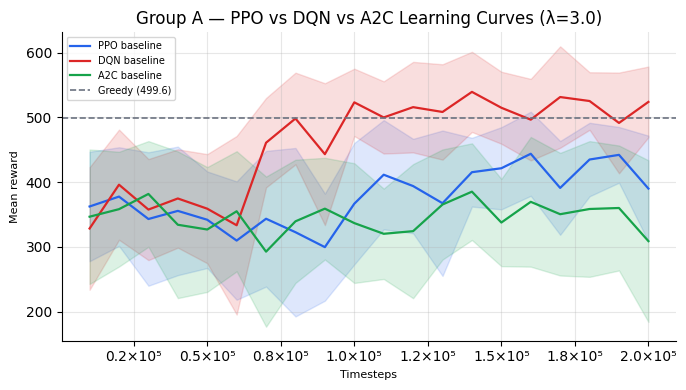

saved A_learning_curves


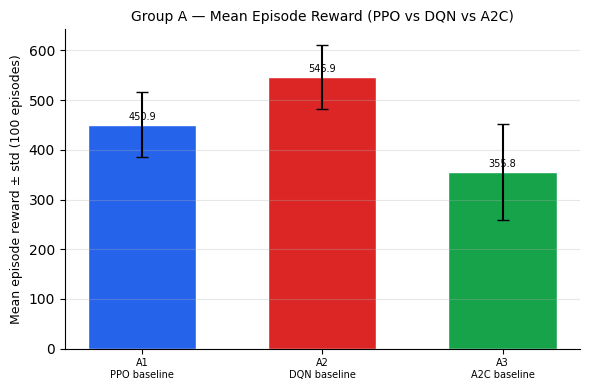

saved A_reward_bar


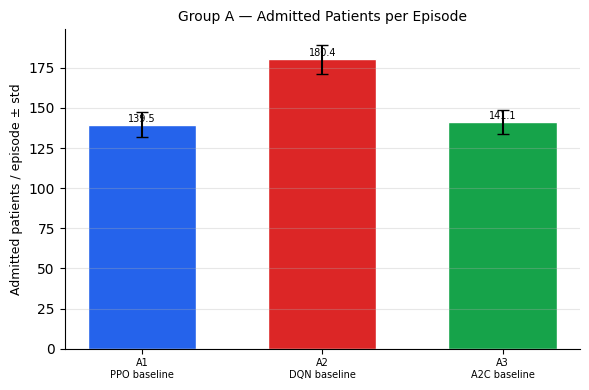

saved A_admitted_bar


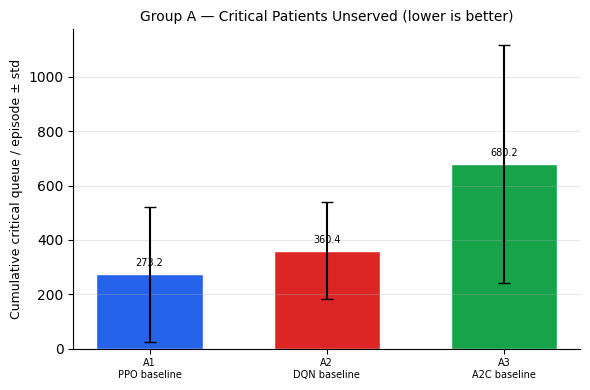

saved A_unserved_bar


In [ ]:
#  Group A: Algorithm Comparison (PPO vs DQN vs A2C at λ=3.0)

GROUP_A = ["A1", "A2", "A3"]

for eid in GROUP_A:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f} ± {res['std_admitted']:.1f}"
          f"  redirected={res['mean_redirected']:.1f} ± {res['std_redirected']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f} ± {res['std_unserved']:.1f}")

# Print comparison table vs greedy
greedy_r = evaluate_greedy()
print(f"\n  Greedy  reward={greedy_r['mean_reward']:.2f} ± {greedy_r['std_reward']:.2f}"
      f"  admitted={greedy_r['mean_admitted']:.1f}"
      f"  redirected={greedy_r['mean_redirected']:.1f}"
      f"  crit_unserved={greedy_r['mean_unserved']:.1f}")

# Learning curves
fig, ax = plt.subplots(figsize=(7, 4))
for eid, col in zip(GROUP_A, GROUP_COLORS["A"]):
    _, _, _, _, lbl = EXPERIMENTS[eid]
    plot_curve(eid, lbl.split(" ", 1)[1], ax=ax, color=col)
ax.axhline(greedy_r['mean_reward'], color="#6B7280", linestyle="--",
           lw=1.2, label=f"Greedy ({greedy_r['mean_reward']:.1f})")
ax.legend(fontsize=7)
ax.set_title("Group A — PPO vs DQN vs A2C Learning Curves (λ=3.0)")
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(FIGURES / f"A_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved A_learning_curves")

bar_chart(GROUP_A, ALL_RESULTS, "reward",
          "Group A — Mean Episode Reward (PPO vs DQN vs A2C)", "A_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)",
          colors=GROUP_COLORS["A"])
bar_chart(GROUP_A, ALL_RESULTS, "admitted",
          "Group A — Admitted Patients per Episode", "A_admitted_bar",
          ylabel="Admitted patients / episode ± std",
          colors=GROUP_COLORS["A"])
bar_chart(GROUP_A, ALL_RESULTS, "unserved",
          "Group A — Critical Patients Unserved (lower is better)", "A_unserved_bar",
          ylabel="Cumulative critical queue / episode ± std",
          colors=GROUP_COLORS["A"])


  [B1]  Loading saved model (PPO) ← output/models/B1/best_model.zip
  B1  reward=507.11 ± 45.58  admitted=138.2 ± 7.2  crit_unserved=57.8 ± 26.0
  [B2]  Loading saved model (DQN) ← output/models/B2/best_model.zip
  B2  reward=655.77 ± 47.64  admitted=186.0 ± 5.9  crit_unserved=78.4 ± 26.8
  [B3]  Loading saved model (A2C) ← output/models/B3/best_model.zip
  B3  reward=485.45 ± 53.66  admitted=140.2 ± 7.4  crit_unserved=78.9 ± 37.7
  [B4]  Loading saved model (PPO) ← output/models/B4/best_model.zip
  B4  reward=334.23 ± 84.21  admitted=123.1 ± 8.2  crit_unserved=757.2 ± 397.6
  [B5]  Loading saved model (DQN) ← output/models/B5/best_model.zip
  B5  reward=359.84 ± 124.21  admitted=147.1 ± 7.1  crit_unserved=1184.1 ± 687.5
  [B6]  Loading saved model (A2C) ← output/models/B6/best_model.zip
  B6  reward=58.48 ± 83.22  admitted=140.3 ± 7.2  crit_unserved=2583.2 ± 361.2
  [B7]  Loading saved model (PPO) ← output/models/B7/best_model.zip
  B7  reward=84.79 ± 82.55  admitted=168.9 ± 8.7  crit

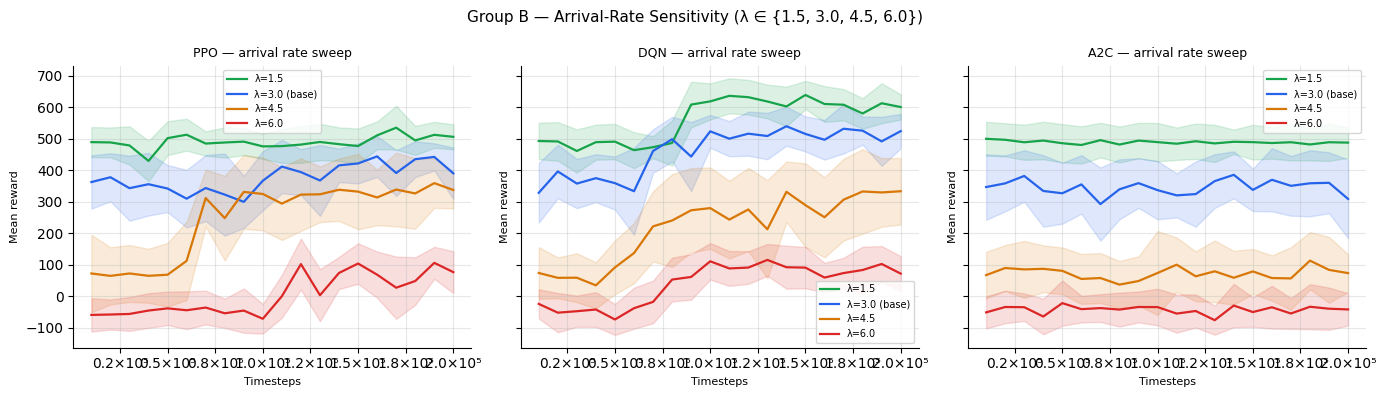

saved B_learning_curves


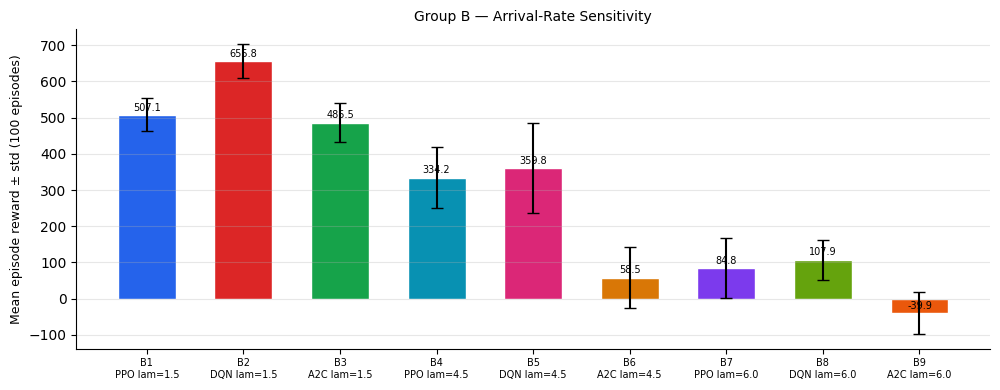

saved B_reward_bar


In [ ]:
#  Group B: Arrival-Rate Sweep (λ ∈ {1.5, 3.0, 4.5, 6.0})

GROUP_B = ["B1","B2","B3","B4","B5","B6","B7","B8","B9"]

for eid in GROUP_B:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f} ± {res['std_admitted']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f} ± {res['std_unserved']:.1f}")

# Learning curves — one panel per algorithm
rate_groups = [
    ("PPO", ["B1","A1","B4","B7"]),
    ("DQN", ["B2","A2","B5","B8"]),
    ("A2C", ["B3","A3","B6","B9"]),
]
rate_colors = ["#16A34A","#2563EB","#D97706","#DC2626"]
rate_labels = ["λ=1.5", "λ=3.0 (base)", "λ=4.5", "λ=6.0"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (algo, ids) in zip(axes, rate_groups):
    for eid, col, lbl in zip(ids, rate_colors, rate_labels):
        if eid in trained:
            plot_curve(eid, lbl, ax=ax, color=col)
    ax.set_title(f"{algo} — arrival rate sweep", fontsize=9)
fig.suptitle("Group B — Arrival-Rate Sensitivity (λ ∈ {1.5, 3.0, 4.5, 6.0})", fontsize=11)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"B_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved B_learning_curves")

bar_chart(GROUP_B, ALL_RESULTS, "reward",
          "Group B — Arrival-Rate Sensitivity", "B_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)", colors=GROUP_COLORS["B"])


  [C1]  Loading saved model (PPO) ← output/models/C1/best_model.zip
  C1  reward=273.27 ± 46.16  admitted=135.0 ± 6.9  crit_unserved=233.5 ± 185.4
  [C2]  Loading saved model (DQN) ← output/models/C2/best_model.zip
  C2  reward=344.87 ± 62.13  admitted=172.9 ± 6.6  crit_unserved=534.3 ± 347.3
  [C3]  Loading saved model (A2C) ← output/models/C3/best_model.zip
  C3  reward=199.83 ± 77.86  admitted=141.1 ± 7.6  crit_unserved=680.2 ± 438.6
  [C4]  Loading saved model (PPO) ← output/models/C4/best_model.zip
  C4  reward=742.33 ± 45.64  admitted=141.1 ± 7.6  crit_unserved=680.2 ± 438.6
  [C5]  Loading saved model (DQN) ← output/models/C5/best_model.zip
  C5  reward=886.88 ± 37.32  admitted=175.5 ± 6.7  crit_unserved=530.5 ± 372.4
  [C6]  Loading saved model (A2C) ← output/models/C6/best_model.zip
  C6  reward=742.33 ± 45.64  admitted=141.1 ± 7.6  crit_unserved=680.2 ± 438.6
  [C7]  Loading saved model (PPO) ← output/models/C7/best_model.zip
  C7  reward=671.53 ± 46.27  admitted=141.2 ± 7.5 

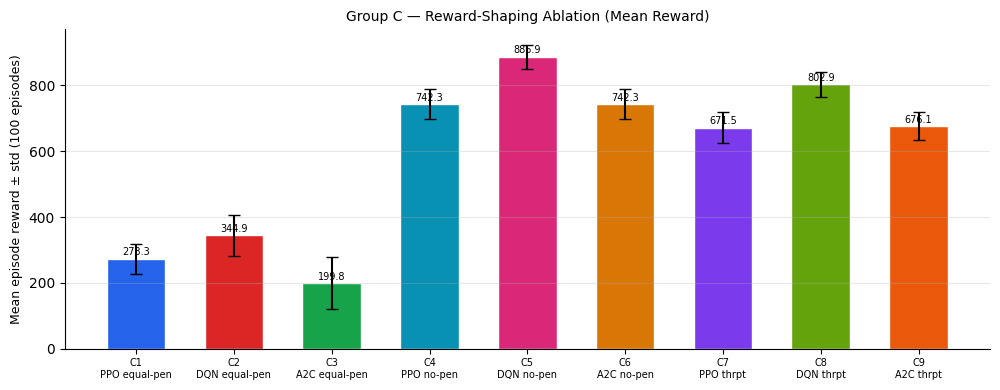

saved C_reward_bar


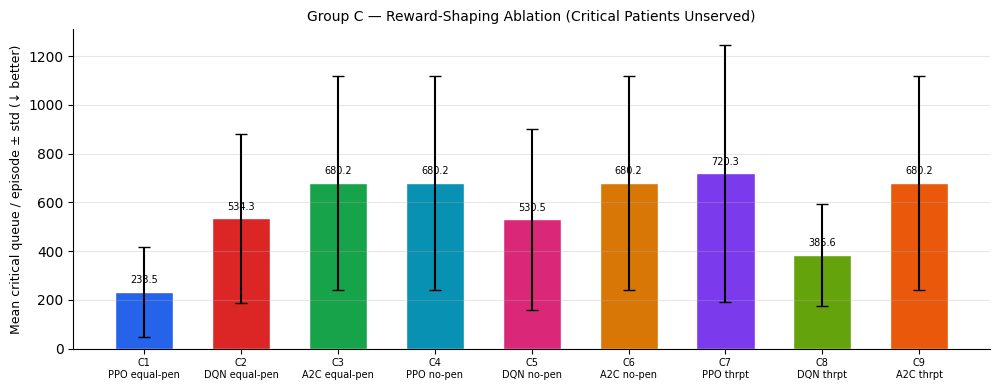

saved C_unserved_bar


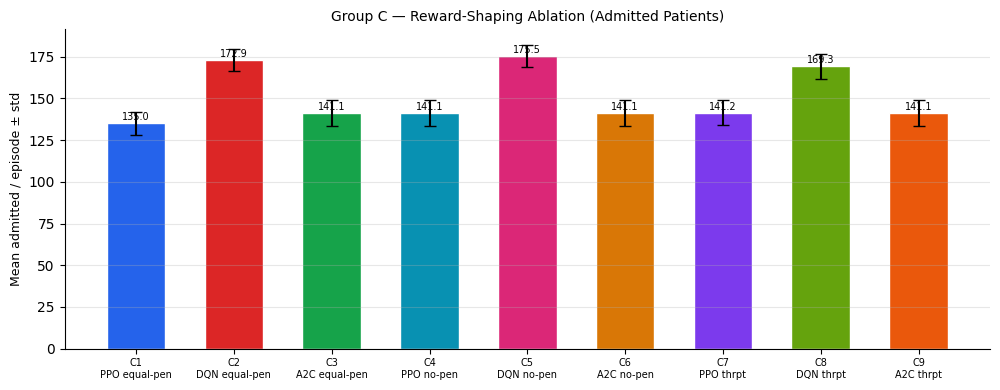

saved C_admitted_bar


In [ ]:
#  Group C: Reward-Shaping Ablation

GROUP_C = ["C1","C2","C3","C4","C5","C6","C7","C8","C9"]

for eid in GROUP_C:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f} ± {res['std_admitted']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f} ± {res['std_unserved']:.1f}")

bar_chart(GROUP_C, ALL_RESULTS, "reward",
          "Group C — Reward-Shaping Ablation (Mean Reward)", "C_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)", colors=GROUP_COLORS["C"])
bar_chart(GROUP_C, ALL_RESULTS, "unserved",
          "Group C — Reward-Shaping Ablation (Critical Patients Unserved)", "C_unserved_bar",
          ylabel="Mean critical queue / episode ± std (↓ better)", colors=GROUP_COLORS["C"])
bar_chart(GROUP_C, ALL_RESULTS, "admitted",
          "Group C — Reward-Shaping Ablation (Admitted Patients)", "C_admitted_bar",
          ylabel="Mean admitted / episode ± std", colors=GROUP_COLORS["C"])


  [D1]  Loading saved model (PPO) ← output/models/D1/best_model.zip
  D1  reward=239.14 ± 41.73  admitted=117.0 ± 8.6  crit_unserved=312.9 ± 92.9
  [D2]  Loading saved model (DQN) ← output/models/D2/best_model.zip
  D2  reward=241.67 ± 61.63  admitted=117.6 ± 9.8  crit_unserved=387.1 ± 268.9
  [D3]  Loading saved model (A2C) ← output/models/D3/best_model.zip
  D3  reward=-31.00 ± 20.27  admitted=18.3 ± 4.8  crit_unserved=146.2 ± 144.3
  [D4]  Loading saved model (PPO) ← output/models/D4/best_model.zip
  D4  reward=551.84 ± 65.04  admitted=152.4 ± 10.0  crit_unserved=176.7 ± 191.3
  [D5]  Loading saved model (DQN) ← output/models/D5/best_model.zip
  D5  reward=723.98 ± 33.42  admitted=188.2 ± 4.8  crit_unserved=130.9 ± 63.3
  [D6]  Loading saved model (A2C) ← output/models/D6/best_model.zip
  D6  reward=491.75 ± 78.55  admitted=157.5 ± 8.9  crit_unserved=421.3 ± 234.9


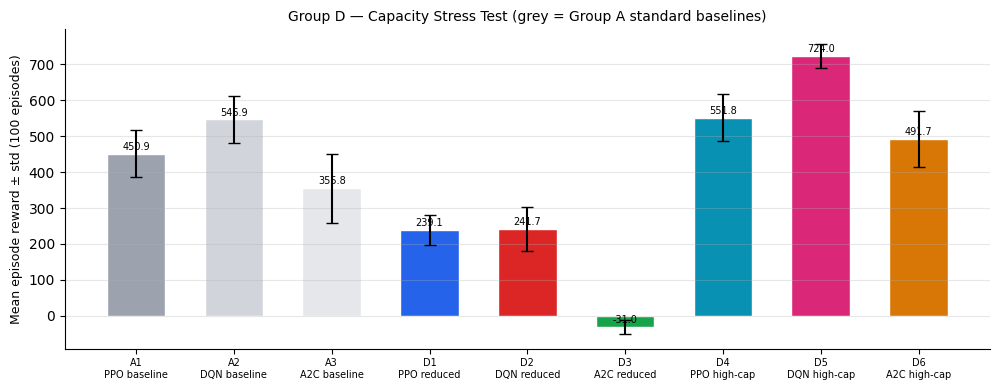

saved D_reward_bar


In [ ]:
#  Group D: Capacity Stress Test

GROUP_D = ["D1","D2","D3","D4","D5","D6"]

for eid in GROUP_D:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f} ± {res['std_admitted']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f} ± {res['std_unserved']:.1f}")

ctx_ids    = ["A1","A2","A3"] + GROUP_D
ctx_colors = ["#9CA3AF","#D1D5DB","#E5E7EB"] + GROUP_COLORS["D"]
bar_chart(ctx_ids, ALL_RESULTS, "reward",
          "Group D — Capacity Stress Test (grey = Group A standard baselines)",
          "D_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)", colors=ctx_colors)


  [E2]  Loading saved model (PPO) ← output/models/E2/best_model.zip
  E2  reward=457.43 ± 50.39  admitted=136.6 ± 8.1
  [E3]  Loading saved model (PPO) ← output/models/E3/best_model.zip
  E3  reward=444.53 ± 44.56  admitted=137.6 ± 6.4


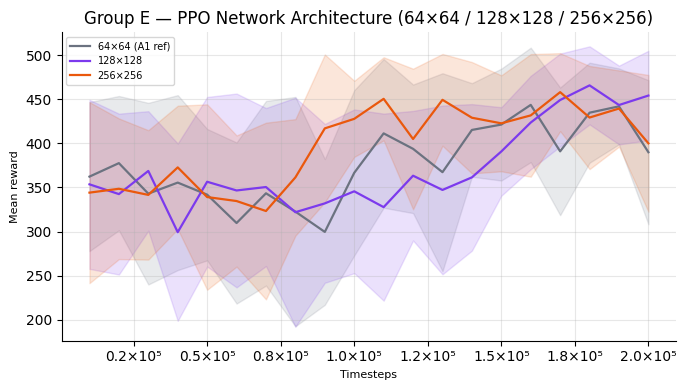

saved E_learning_curves


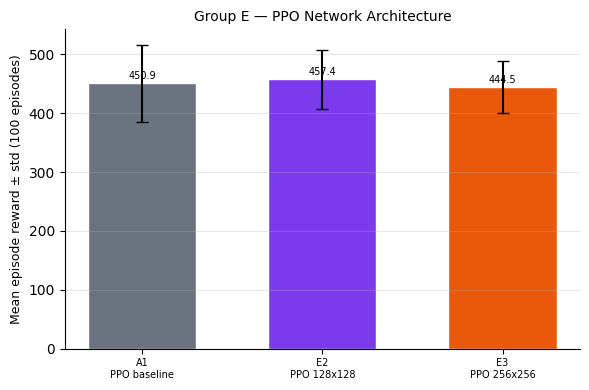

saved E_reward_bar


In [ ]:
#  Group E: PPO Network Architecture

for eid in ["E2","E3"]:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f} ± {res['std_admitted']:.1f}")

GROUP_E_ids    = ["A1", "E2", "E3"]
GROUP_E_labels = {"A1": "64×64 (A1 ref)", "E2": "128×128", "E3": "256×256"}

fig, ax = plt.subplots(figsize=(7, 4))
for eid, col in zip(GROUP_E_ids, GROUP_COLORS["E"]):
    if eid in trained:
        plot_curve(eid, GROUP_E_labels[eid], ax=ax, color=col)
ax.set_title("Group E — PPO Network Architecture (64×64 / 128×128 / 256×256)")
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"E_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved E_learning_curves")

bar_chart(GROUP_E_ids, ALL_RESULTS, "reward",
          "Group E — PPO Network Architecture", "E_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)", colors=GROUP_COLORS["E"])


  [F1]  Loading saved model (PPO) ← output/models/F1/best_model.zip
  F1  reward=464.97 ± 40.69  admitted=133.6 ± 7.4
  [F2]  Loading saved model (PPO) ← output/models/F2/best_model.zip
  F2  reward=355.76 ± 96.10  admitted=141.1 ± 7.6
  [F3]  Loading saved model (PPO) ← output/models/F3/best_model.zip
  F3  reward=432.44 ± 50.12  admitted=131.7 ± 7.3
  [F4]  Loading saved model (PPO) ← output/models/F4/best_model.zip
  F4  reward=453.98 ± 44.03  admitted=135.8 ± 7.4


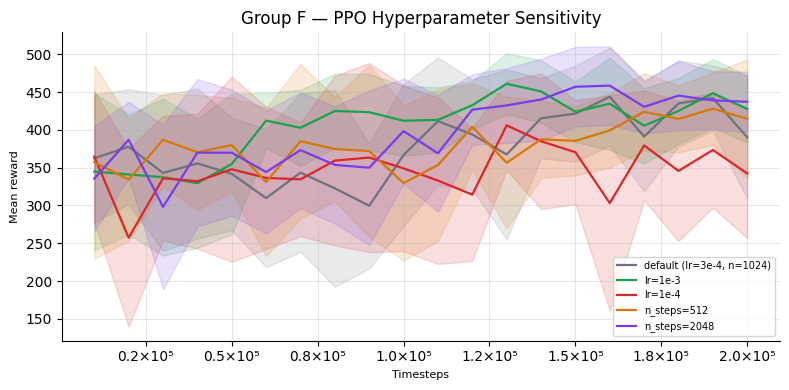

saved F_learning_curves


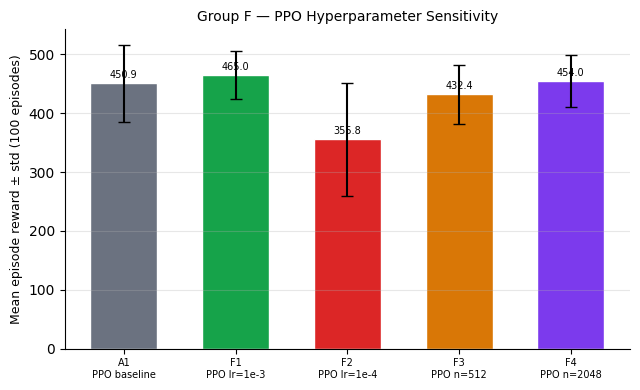

saved F_reward_bar


In [ ]:
#  Group F: PPO Hyperparameter Sensitivity

for eid in ["F1","F2","F3","F4"]:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid)
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f} ± {res['std_admitted']:.1f}")

GROUP_F_all = ["A1","F1","F2","F3","F4"]
F_labels = {
    "A1": "default (lr=3e-4, n=1024)",
    "F1": "lr=1e-3", "F2": "lr=1e-4",
    "F3": "n_steps=512", "F4": "n_steps=2048",
}
fig, ax = plt.subplots(figsize=(8, 4))
for eid, col in zip(GROUP_F_all, GROUP_COLORS["F"]):
    if eid in trained:
        plot_curve(eid, F_labels[eid], ax=ax, color=col)
ax.set_title("Group F — PPO Hyperparameter Sensitivity")
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"F_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved F_learning_curves")

bar_chart(GROUP_F_all, ALL_RESULTS, "reward",
          "Group F — PPO Hyperparameter Sensitivity", "F_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)", colors=GROUP_COLORS["F"])


---

## Groups Replication — Seed Robustness Check

These cells re-run Groups A and B with a different training seed (`REPLICATION_SEED=123`) to verify that the main results are not artefacts of a single random seed. Results from a different training seed should differ meaningfully from the originals for PPO and DQN, confirming that training is stochastic but stable, while A2C is expected to converge to the same policy regardless of seed.

  [A1f]  Loading saved model (PPO) ← output/models/A1f/best_model.zip
  A1f  reward=447.13 ± 41.04  admitted=134.0 ± 7.0  redirected=38.9 ± 7.3  crit_unserved=198.9 ± 80.4
  [A2f]  Loading saved model (DQN) ← output/models/A2f/best_model.zip
  A2f  reward=532.10 ± 58.27  admitted=161.8 ± 8.0  redirected=6.3 ± 3.8  crit_unserved=307.9 ± 154.9
  [A3f]  Loading saved model (A2C) ← output/models/A3f/best_model.zip
  A3f  reward=356.63 ± 91.36  admitted=141.4 ± 7.3  redirected=0.0 ± 0.0  crit_unserved=692.1 ± 414.1

─── Replication Check: Group A vs A_fixed ────────────────────
Condition                    Reward     Admitted     Redirected
───────────────────────────────────────────────────────────────
  A1 (orig) :  reward= 450.91 ± 65.64  admitted=139.5 ±  7.7  redirected= 27.8 ±  9.6
  A1f (repl) :  reward= 447.13 ± 41.04  admitted=134.0 ±  7.0  redirected= 38.9 ±  7.3

  A2 (orig) :  reward= 546.92 ± 64.88  admitted=180.4 ±  9.1  redirected=  0.6 ±  1.0
  A2f (repl) :  reward= 532.10 ±

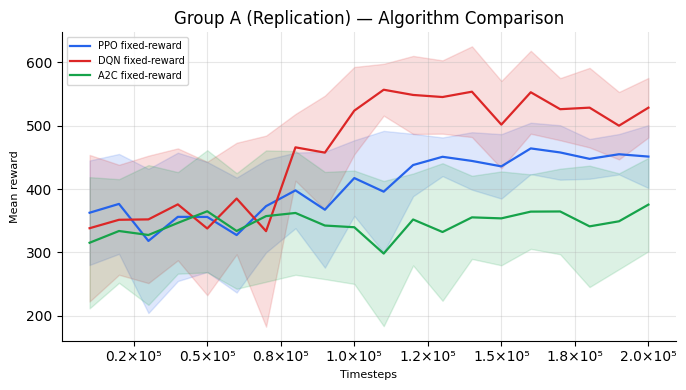

saved A_fixed_learning_curves


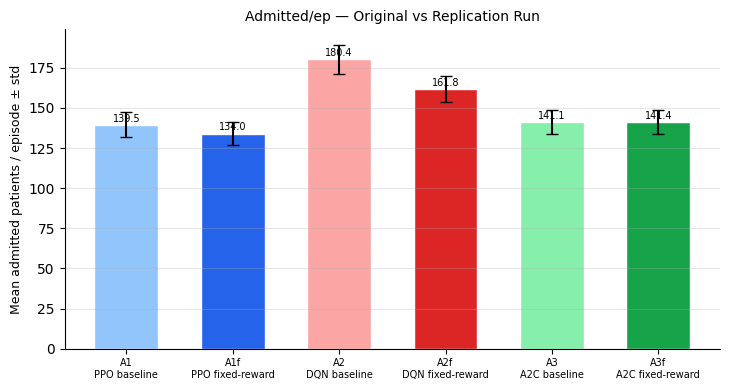

saved A_replication_comparison


In [ ]:
#  Group A Replication (Fixed Reward)

GROUP_A_FIXED = ["A1f","A2f","A3f"]

for eid in GROUP_A_FIXED:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid, seed=200)  # different eval seed from originals
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f} ± {res['std_admitted']:.1f}"
          f"  redirected={res['mean_redirected']:.1f} ± {res['std_redirected']:.1f}"
          f"  crit_unserved={res['mean_unserved']:.1f} ± {res['std_unserved']:.1f}")

print("\n─── Replication Check: Group A vs A_fixed ────────────────────")
header = f"{'Condition':<22} {'Reward':>12} {'Admitted':>12} {'Redirected':>14}"
print(header)
print("─" * len(header))
for old, new in [("A1","A1f"), ("A2","A2f"), ("A3","A3f")]:
    for eid, tag in [(old, "orig"), (new, "repl")]:
        if eid in ALL_RESULTS:
            r = ALL_RESULTS[eid]
            print(f"  {eid} ({tag}) :"
                  f"  reward={r['reward']['mean']:7.2f} ± {r['reward']['std']:5.2f}"
                  f"  admitted={r['admitted']['mean']:5.1f} ± {r['admitted']['std']:4.1f}"
                  f"  redirected={r['redirected']['mean']:5.1f} ± {r['redirected']['std']:4.1f}")
    print()

fig, ax = plt.subplots(figsize=(7, 4))
for eid, col in zip(GROUP_A_FIXED, GROUP_COLORS["A_fixed"]):
    _, _, _, _, lbl = EXPERIMENTS[eid]
    plot_curve(eid, lbl.split(" ", 1)[1], ax=ax, color=col)
ax.set_title("Group A (Replication) — Algorithm Comparison")
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"A_fixed_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved A_fixed_learning_curves")

compare_ids    = ["A1","A1f","A2","A2f","A3","A3f"]
compare_colors = ["#93C5FD","#2563EB","#FCA5A5","#DC2626","#86EFAC","#16A34A"]
bar_chart(compare_ids, ALL_RESULTS, "admitted",
          "Admitted/ep — Original vs Replication Run",
          "A_replication_comparison",
          ylabel="Mean admitted patients / episode ± std",
          colors=compare_colors)


  [B1f]  Loading saved model (PPO) ← output/models/B1f/best_model.zip
  B1f  reward=480.74 ± 53.09  admitted=139.3 ± 7.6
  [B2f]  Loading saved model (DQN) ← output/models/B2f/best_model.zip
  B2f  reward=635.22 ± 51.57  admitted=166.0 ± 8.3
  [B3f]  Loading saved model (A2C) ← output/models/B3f/best_model.zip
  B3f  reward=480.74 ± 53.09  admitted=139.3 ± 7.6
  [B4f]  Loading saved model (PPO) ← output/models/B4f/best_model.zip
  B4f  reward=324.30 ± 92.84  admitted=121.4 ± 6.2
  [B5f]  Loading saved model (DQN) ← output/models/B5f/best_model.zip
  B5f  reward=358.40 ± 106.76  admitted=148.0 ± 9.2
  [B6f]  Loading saved model (A2C) ← output/models/B6f/best_model.zip
  B6f  reward=57.82 ± 93.86  admitted=140.2 ± 7.8
  [B7f]  Loading saved model (PPO) ← output/models/B7f/best_model.zip
  B7f  reward=87.11 ± 56.78  admitted=169.2 ± 8.1
  [B8f]  Loading saved model (DQN) ← output/models/B8f/best_model.zip
  B8f  reward=97.59 ± 63.67  admitted=165.5 ± 8.3
  [B9f]  Loading saved model (A2C)

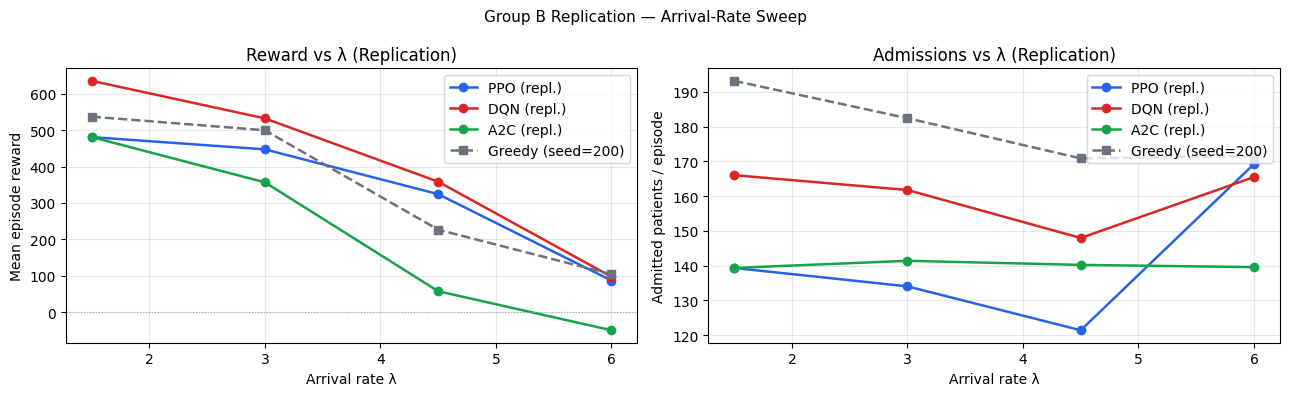

saved B_replication_lambda_sweep


In [ ]:
#  Group B Replication (Fixed Reward, Arrival-Rate Sweep)

GROUP_B_FIXED = ["B1f","B2f","B3f","B4f","B5f","B6f","B7f","B8f","B9f"]

for eid in GROUP_B_FIXED:
    trained[eid] = run_experiment(eid)
    res = evaluate_model(trained[eid], eid, seed=200)  # different eval seed from originals
    store(eid, res)
    print(f"  {eid}  reward={res['mean_reward']:.2f} ± {res['std_reward']:.2f}"
          f"  admitted={res['mean_admitted']:.1f} ± {res['std_admitted']:.1f}")

lambdas     = [1.5, 3.0, 4.5, 6.0]
ppo_f_ids   = ["B1f","A1f","B4f","B7f"]
dqn_f_ids   = ["B2f","A2f","B5f","B8f"]
a2c_f_ids   = ["B3f","A3f","B6f","B9f"]
greedy_keys = ["Greedy-1.5","Greedy-3.0","Greedy-4.5","Greedy-6.0"]

# Dedicated seed=200 greedy reference, matched to the replication eval seed
greedy_repl_200 = {lam: evaluate_greedy(arrival_rate=lam, n_episodes=100, seed=200)
                   for lam in lambdas}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ids, lbl, col in [(ppo_f_ids,"PPO (repl.)","#2563EB"),
                       (dqn_f_ids,"DQN (repl.)","#DC2626"),
                       (a2c_f_ids,"A2C (repl.)","#16A34A")]:
    rews  = [ALL_RESULTS[k]["reward"]["mean"]   for k in ids if k in ALL_RESULTS]
    adms  = [ALL_RESULTS[k]["admitted"]["mean"] for k in ids if k in ALL_RESULTS]
    lams  = [l for k, l in zip(ids, lambdas)   if k in ALL_RESULTS]
    ax1.plot(lams, rews, marker="o", label=lbl, color=col, lw=1.8)
    ax2.plot(lams, adms, marker="o", label=lbl, color=col, lw=1.8)

g_lams = lambdas
g_rews = [greedy_repl_200[lam]["mean_reward"]   for lam in lambdas]
g_adms = [greedy_repl_200[lam]["mean_admitted"] for lam in lambdas]
ax1.plot(g_lams, g_rews, marker="s", label="Greedy (seed=200)", color="#6B7280", lw=1.8, linestyle="--")
ax2.plot(g_lams, g_adms, marker="s", label="Greedy (seed=200)", color="#6B7280", lw=1.8, linestyle="--")

ax1.axhline(0, color="#9CA3AF", lw=0.8, linestyle=":")
ax1.set_xlabel("Arrival rate λ"); ax1.set_ylabel("Mean episode reward")
ax1.set_title("Reward vs λ (Replication)"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xlabel("Arrival rate λ"); ax2.set_ylabel("Admitted patients / episode")
ax2.set_title("Admissions vs λ (Replication)"); ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle("Group B Replication — Arrival-Rate Sweep", fontsize=11)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"B_replication_lambda_sweep.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved B_replication_lambda_sweep")


In [ ]:
# Greedy Baselines at All Arrival Rates

GREEDY_RATES = [1.5, 3.0, 4.5, 6.0]

print("Greedy baselines across arrival rates:")
for lam in GREEDY_RATES:
    g   = evaluate_greedy(arrival_rate=lam, n_episodes=100)
    key = f"Greedy-{lam}"
    ALL_RESULTS[key] = {
        "label":      f"Greedy λ={lam}",
        "reward":     {"mean": g["mean_reward"],     "std": g["std_reward"]},
        "admitted":   {"mean": g["mean_admitted"],   "std": g["std_admitted"]},
        "redirected": {"mean": g["mean_redirected"], "std": g["std_redirected"]},
        "unserved":   {"mean": g["mean_unserved"],   "std": g["std_unserved"]},
        "deaths":     {"mean": g.get("mean_deaths",  0.0), "std": g.get("std_deaths", 0.0)},
    }
    print(f"  λ={lam}: reward={g['mean_reward']:.2f} ± {g['std_reward']:.2f}"
          f"  admitted={g['mean_admitted']:.1f} ± {g['std_admitted']:.1f}"
          f"  crit_unserved={g['mean_unserved']:.1f} ± {g['std_unserved']:.1f}")

Greedy baselines across arrival rates:
  λ=1.5: reward=532.02 ± 39.75  admitted=192.8 ± 3.9  crit_unserved=73.1 ± 13.7
  λ=3.0: reward=499.57 ± 61.94  admitted=183.3 ± 8.3  crit_unserved=363.7 ± 294.2
  λ=4.5: reward=235.53 ± 112.72  admitted=171.4 ± 8.2  crit_unserved=2300.8 ± 592.4
  λ=6.0: reward=105.01 ± 59.50  admitted=172.5 ± 7.9  crit_unserved=3229.7 ± 210.9


---

## Analysis & Visualisation

Summary table, cross-group bar chart, action-distribution breakdown, multi-seed robustness check, and A2C failure analysis.

In [ ]:
# Intermediate Results Table (Groups A-K only)
# This saves a partial CSV for inspection during the notebook run.

ORDER = (
      ["A1","A2","A3"]
    + ["B1","B2","B3","B4","B5","B6","B7","B8","B9"]
    + ["C1","C2","C3","C4","C5","C6","C7","C8","C9"]
    + ["D1","D2","D3","D4","D5","D6"]
    + ["E2","E3"]
    + ["F1","F2","F3","F4"]
    + [f"Greedy-{l}" for l in [1.5, 3.0, 4.5, 6.0]]
    + ["A1f","A2f","A3f"]
    + ["B1f","B2f","B3f","B4f","B5f","B6f","B7f","B8f","B9f"]
    + ["G1","G2","G3"]
    + ["H1","H2","H3","H4","H5"]
)

rows = []
seen = set()
for eid in ORDER:
    if eid in ALL_RESULTS and eid not in seen:
        seen.add(eid)
        r = ALL_RESULTS[eid]
        rows.append({
            "ID":                 eid,
            "Condition":          r["label"],
            "Mean Reward":        f"{r['reward']['mean']:.2f}",
            "Std Reward":         f"{r['reward']['std']:.2f}",
            "Admitted/ep":        f"{r['admitted']['mean']:.1f}",
            "Std Admitted":       f"{r['admitted']['std']:.1f}",
            "Redirected/ep":      f"{r['redirected']['mean']:.1f}",
            "Std Redirected":     f"{r['redirected']['std']:.1f}",
            "Crit Unserved":      f"{r['unserved']['mean']:.1f}",
            "Std Crit Unserved":  f"{r['unserved']['std']:.1f}",
            "Deaths/ep":          f"{r.get('deaths', {}).get('mean', 0.0):.1f}",
            "Std Deaths":         f"{r.get('deaths', {}).get('std',  0.0):.1f}",
            "Overflow/ep":         f"{r.get('overflow', {}).get('mean', 0.0):.1f}",
            "Std Overflow":        f"{r.get('overflow', {}).get('std',  0.0):.1f}",
        })

df = pd.DataFrame(rows)
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)
print(df.to_string(index=False))

csv_path = OUT / "results_master.csv"
df.to_csv(csv_path, index=False)
print(f"\nsaved {csv_path}  ({len(rows)} rows)")
print("All metrics populated with real std values.")


        ID         Condition Mean Reward Std Reward Admitted/ep Std Admitted Redirected/ep Std Redirected Crit Unserved Std Crit Unserved Deaths/ep Std Deaths Overflow/ep Std Overflow
        A1      PPO baseline      450.91      65.64       139.5          7.7          27.8            9.6         273.2             246.9       0.0        0.0       394.9         23.1
        A2      DQN baseline      546.92      64.88       180.4          9.1           0.6            1.0         360.4             177.7       0.0        0.0       379.7         22.9
        A3      A2C baseline      355.76      96.10       141.1          7.6           0.0            0.0         680.2             438.6       0.0        0.0       418.1         22.4
        B1       PPO lam=1.5      507.11      45.58       138.2          7.2          17.9            5.4          57.8              26.0       0.0        0.0       107.4         15.4
        B2       DQN lam=1.5      655.77      47.64       186.0          5.9    

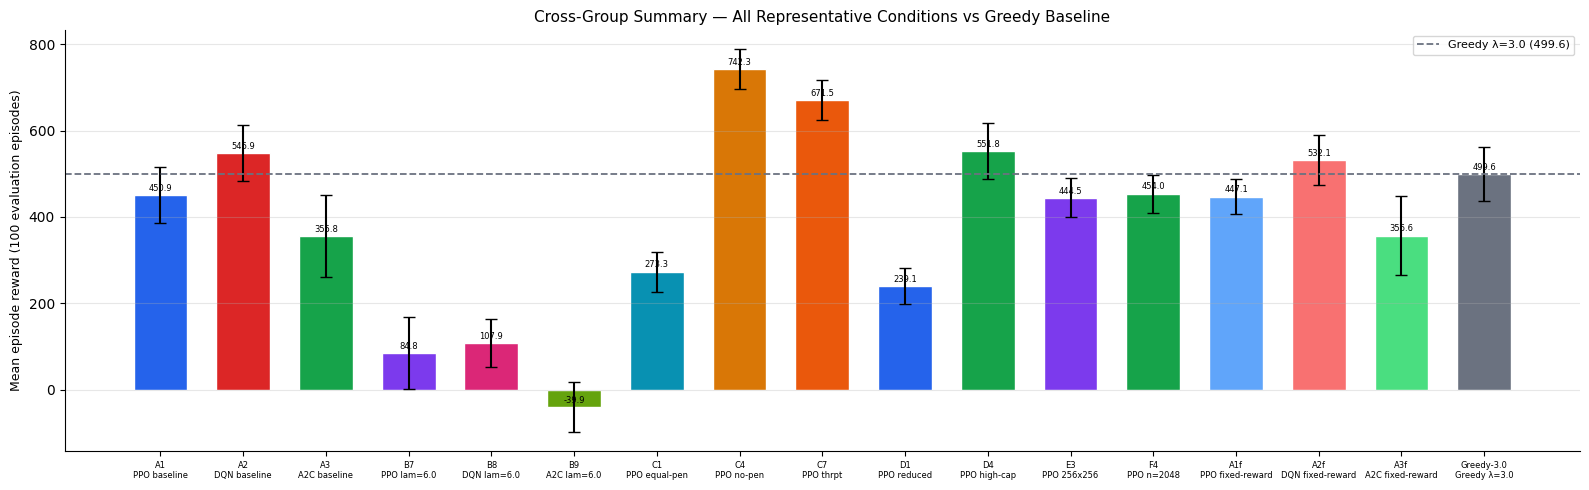

saved summary_bar


In [ ]:
# Cross-Group Summary Bar Chart

SUMMARY_PLAN = [
    ("A1",        "#2563EB"), ("A2",  "#DC2626"), ("A3",  "#16A34A"),
    ("B7",        "#7C3AED"), ("B8",  "#DB2777"), ("B9",  "#65A30D"),
    ("C1",        "#0891B2"), ("C4",  "#D97706"), ("C7",  "#EA580C"),
    ("D1",        "#2563EB"), ("D4",  "#16A34A"),
    ("E3",        "#7C3AED"), ("F4",  "#16A34A"),
    ("A1f",       "#60A5FA"), ("A2f", "#F87171"), ("A3f", "#4ADE80"),
    ("Greedy-3.0","#6B7280"),
]

valid  = [(eid, col) for eid, col in SUMMARY_PLAN if eid in ALL_RESULTS]
ids    = [e for e, _ in valid]
cols   = [c for _, c in valid]
labels = [ALL_RESULTS[i]["label"]         for i in ids]
means  = [ALL_RESULTS[i]["reward"]["mean"] for i in ids]
stds   = [ALL_RESULTS[i]["reward"]["std"]  for i in ids]

fig, ax = plt.subplots(figsize=(16, 5))
x    = np.arange(len(ids))
bars = ax.bar(x, means, yerr=stds, color=cols, capsize=4,
              edgecolor="white", width=0.65)
for bar, m in zip(bars, means):
    top = bar.get_height() + (max(stds) if stds else 0) * 0.05 + 0.2
    ax.text(bar.get_x() + bar.get_width() / 2, top,
            f"{m:.1f}", ha="center", va="bottom", fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels([f"{i}\n{l}" for i, l in zip(ids, labels)], fontsize=6)

gv = ALL_RESULTS.get("Greedy-3.0", {}).get("reward", {}).get("mean", 0)
ax.axhline(gv, color="#6B7280", linestyle="--", lw=1.3,
           label=f"Greedy λ=3.0 ({gv:.1f})")
ax.set_ylabel("Mean episode reward (100 evaluation episodes)", fontsize=9)
ax.set_title("Cross-Group Summary — All Representative Conditions vs Greedy Baseline", fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"summary_bar.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved summary_bar")

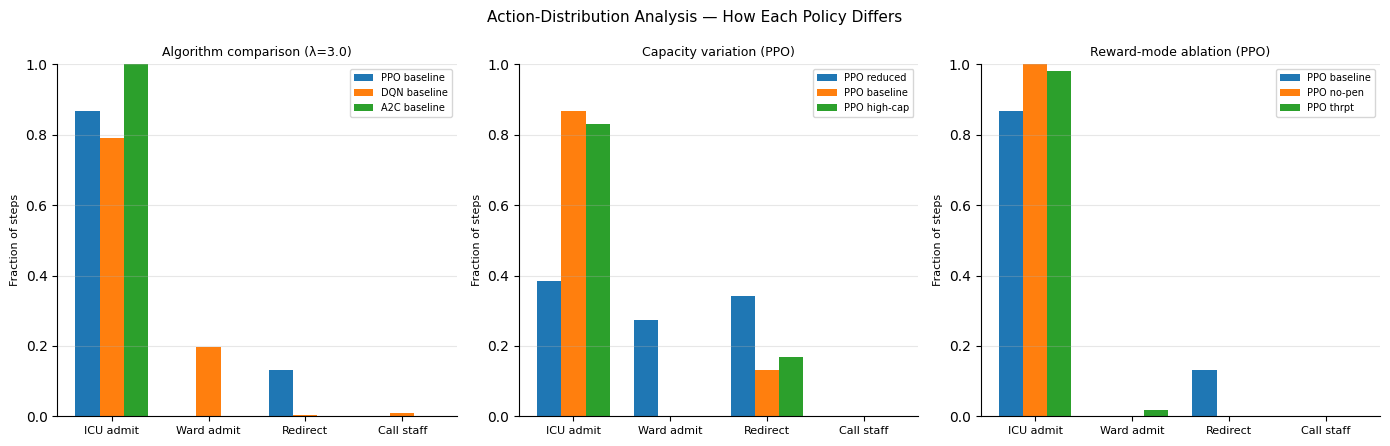

saved action_distribution


In [ ]:
# Action Distribution Analysis

def action_dist(model, exp_id, n_episodes=50, seed=77):
    _, env_kwargs, _, _, _ = EXPERIMENTS[exp_id]
    env    = HospitalEnv(**env_kwargs)
    rng    = np.random.default_rng(seed)
    counts = np.zeros(4)
    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        done   = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            counts[int(action)] += 1
            obs, _, done, _, _ = env.step(int(action))
    return counts / counts.sum()


panels = [
    ("Algorithm comparison (λ=3.0)",  ["A1","A2","A3"]),
    ("Capacity variation (PPO)",       ["D1","A1","D4"]),
    ("Reward-mode ablation (PPO)",     ["A1","C4","C7"]),
]
action_labels = ["ICU admit","Ward admit","Redirect","Call staff"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (title, ids) in zip(axes, panels):
    dists, lbls = [], []
    for eid in ids:
        if eid in trained:
            dists.append(action_dist(trained[eid], eid))
            lbls.append(EXPERIMENTS[eid][4].split(" ", 1)[1])
    if not dists:
        ax.set_title(f"{title} (no data)")
        continue
    x = np.arange(4)
    w = 0.25
    for k, (d, l) in enumerate(zip(dists, lbls)):
        ax.bar(x + k * w, d, width=w, label=l)
    ax.set_xticks(x + w * (len(dists) - 1) / 2)
    ax.set_xticklabels(action_labels, fontsize=8)
    ax.set_ylabel("Fraction of steps", fontsize=8)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.set_title(title, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Action-Distribution Analysis — How Each Policy Differs", fontsize=11)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"action_distribution.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved action_distribution")

─── Multi-Seed Robustness: PPO ──────────────────────────────
  [PPO_multiseed_seed42]  Loading saved model (PPO) ← output/models/PPO_multiseed_seed42/best_model.zip
  seed=42: reward=454.30  unserved=238.4
  [PPO_multiseed_seed123]  Loading saved model (PPO) ← output/models/PPO_multiseed_seed123/best_model.zip
  seed=123: reward=416.01  unserved=307.7
  [PPO_multiseed_seed777]  Loading saved model (PPO) ← output/models/PPO_multiseed_seed777/best_model.zip
  seed=777: reward=445.48  unserved=190.0
  PPO → reward: 438.60 ± 16.37  unserved: 245.4 ± 48.3

─── Multi-Seed Robustness: DQN ──────────────────────────────
  [DQN_multiseed_seed42]  Loading saved model (DQN) ← output/models/DQN_multiseed_seed42/best_model.zip
  seed=42: reward=535.19  unserved=344.7
  [DQN_multiseed_seed123]  Loading saved model (DQN) ← output/models/DQN_multiseed_seed123/best_model.zip
  seed=123: reward=543.45  unserved=343.3
  [DQN_multiseed_seed777]  Loading saved model (DQN) ← output/models/DQN_multiseed_see

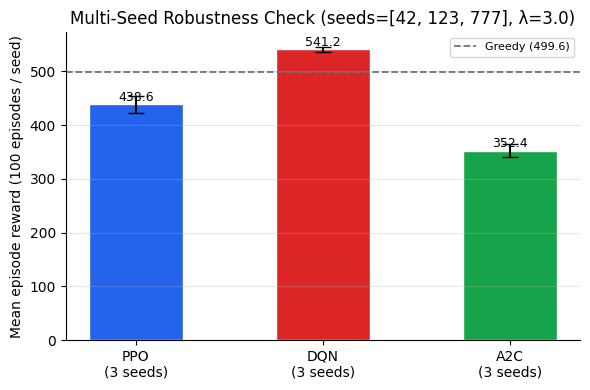

saved multiseed_robustness


In [ ]:
#  Multi-Seed Robustness Check

MULTI_SEEDS = [42, 123, 777]


def run_multi_seed(algo_name, env_kwargs, seeds, label, net_arch=None):
    """Train algorithm on env across multiple seeds; return per-seed eval metrics.
    Saves each model with metadata; loads on subsequent runs."""
    import json as _json
    if net_arch is None:
        net_arch = [64, 64]
    all_rewards  = []
    all_unserved = []

    AlgoCls = {"PPO": PPO, "DQN": DQN, "A2C": A2C}[algo_name]

    for seed in seeds:
        tag       = f"{label}_seed{seed}"
        model_dir = MODELS / tag
        model_dir.mkdir(parents=True, exist_ok=True)
        saved_path = model_dir / "best_model.zip"
        meta_path  = model_dir / "meta.json"

        #  Load if valid saved model exists
        loaded = False
        if saved_path.exists() and meta_path.exists():
            with open(meta_path) as mf:
                meta = _json.load(mf)
            if meta.get("algo_name") == algo_name and meta.get("seed") == seed:
                print(f"  [{tag}]  Loading saved model ({algo_name}) ← {saved_path}")
                train_env = make_env(env_kwargs, seed)
                model = AlgoCls.load(str(saved_path), env=train_env)
                loaded = True

        if not loaded:
            print(f"  [{tag}]  Training {algo_name} seed={seed}")
            train_env = make_env(env_kwargs, seed)
            eval_env  = make_env(env_kwargs, seed + 1)
            hp = dict(ALGO_DEFAULTS[algo_name])

            model = AlgoCls(
                policy        = "MlpPolicy",
                env           = train_env,
                seed          = seed,
                verbose       = 0,
                policy_kwargs = {"net_arch": net_arch},
                **hp,
            )
            cb = EvalCallback(
                eval_env,
                best_model_save_path = str(model_dir),
                log_path             = str(model_dir),
                eval_freq            = 10_000,
                n_eval_episodes      = 10,
                deterministic        = True,
                verbose              = 0,
            )
            model.learn(total_timesteps=TIMESTEPS, callback=cb, progress_bar=True)
            # Save metadata
            with open(meta_path, "w") as mf:
                _json.dump({"algo_name": algo_name, "seed": seed,
                            "label": label, "exp_id": label,
                            "timesteps": TIMESTEPS}, mf, indent=2)

        # Evaluate
        env_eval = HospitalEnv(**env_kwargs)
        rng = np.random.default_rng(seed + 100)
        ep_rewards, ep_unserved = [], []
        for _ in range(100):  # 100 episodes for consistent variance estimation
            obs, _ = env_eval.reset(seed=int(rng.integers(0, 2**31)))
            ep_r = ep_u = 0
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, r, done, _, info = env_eval.step(int(action))
                ep_r += r
                ep_u += info["q_crit"]
            ep_rewards.append(ep_r)
            ep_unserved.append(ep_u)
        all_rewards.append(np.mean(ep_rewards))
        all_unserved.append(np.mean(ep_unserved))
        print(f"  seed={seed}: reward={np.mean(ep_rewards):.2f}  unserved={np.mean(ep_unserved):.1f}")

    return all_rewards, all_unserved


print("─── Multi-Seed Robustness: PPO ──────────────────────────────")
ppo_rewards, ppo_unserved = run_multi_seed("PPO", dict(arrival_rate=3.0),
                                            MULTI_SEEDS, "PPO_multiseed")
print(f"  PPO → reward: {np.mean(ppo_rewards):.2f} ± {np.std(ppo_rewards):.2f}"
      f"  unserved: {np.mean(ppo_unserved):.1f} ± {np.std(ppo_unserved):.1f}")

print("\n─── Multi-Seed Robustness: DQN ──────────────────────────────")
dqn_rewards, dqn_unserved = run_multi_seed("DQN", dict(arrival_rate=3.0),
                                            MULTI_SEEDS, "DQN_multiseed")
print(f"  DQN → reward: {np.mean(dqn_rewards):.2f} ± {np.std(dqn_rewards):.2f}"
      f"  unserved: {np.mean(dqn_unserved):.1f} ± {np.std(dqn_unserved):.1f}")

print("\n─── Multi-Seed Robustness: A2C ──────────────────────────────")
a2c_rewards, a2c_unserved = run_multi_seed("A2C", dict(arrival_rate=3.0),
                                            MULTI_SEEDS, "A2C_multiseed")
print(f"  A2C → reward: {np.mean(a2c_rewards):.2f} ± {np.std(a2c_rewards):.2f}"
      f"  unserved: {np.mean(a2c_unserved):.1f} ± {np.std(a2c_unserved):.1f}")

# Summary bar with error bars
algos     = ["PPO", "DQN", "A2C"]
all_r     = [ppo_rewards, dqn_rewards, a2c_rewards]
means_ms  = [np.mean(r) for r in all_r]
stds_ms   = [np.std(r)  for r in all_r]
colors_ms = ["#2563EB", "#DC2626", "#16A34A"]

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
bars = ax.bar(x, means_ms, yerr=stds_ms, color=colors_ms,
              capsize=6, edgecolor="white", width=0.5)
for bar, m in zip(bars, means_ms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{m:.1f}", ha="center", va="bottom", fontsize=9)

greedy_r_val = ALL_RESULTS.get("Greedy-3.0", {}).get("reward", {}).get("mean", None)
if greedy_r_val:
    ax.axhline(greedy_r_val, color="#6B7280", linestyle="--", lw=1.3,
               label=f"Greedy ({greedy_r_val:.1f})")
    ax.legend(fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"{a}\n({len(MULTI_SEEDS)} seeds)" for a in algos])
ax.set_ylabel("Mean episode reward (100 episodes / seed)")
ax.set_title(f"Multi-Seed Robustness Check (seeds={MULTI_SEEDS}, λ=3.0)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"multiseed_robustness.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved multiseed_robustness")



A2C variant: default
  [A2C_default]  Loading saved model ← output/models/A2C_default/best_model.zip
  → reward = 355.76 ± 96.10

A2C variant: scaled_rew
  [A2C_scaled_rew]  Loading saved model ← output/models/A2C_scaled_rew/best_model.zip
  → reward = 355.76 ± 96.10

A2C variant: low_lr
  [A2C_low_lr]  Loading saved model ← output/models/A2C_low_lr/best_model.zip
  → reward = 355.76 ± 96.10

A2C variant: long_rollout
  [A2C_long_rollout]  Loading saved model ← output/models/A2C_long_rollout/best_model.zip
  → reward = 355.76 ± 96.10

─── A2C Failure Analysis Summary ────────────────────────────
  PPO baseline (A1) : 450.91  ← target
  DQN baseline (A2) : 546.92
  A2C default       : 355.76 ± 96.10
  A2C scaled_rew    : 355.76 ± 96.10
  A2C low_lr        : 355.76 ± 96.10
  A2C long_rollout  : 355.76 ± 96.10

  Best A2C variant  : 'default' (355.76)
  Interpretation    : the variant that improves most points to the
  root cause.  If no variant improves, A2C's failure on this MDP
  is s

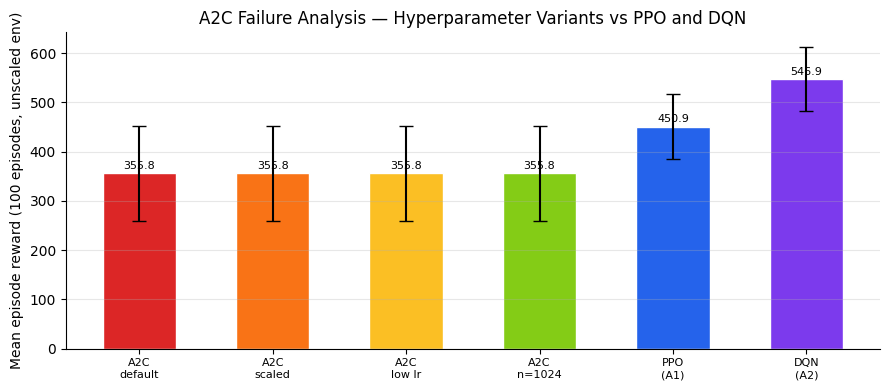

saved a2c_failure_analysis


In [ ]:
#  A2C Failure Analysis

import json as _json20


class ScaledRewardWrapper(gym.Wrapper):
    """Divides all rewards by a constant factor to reduce gradient variance."""
    def __init__(self, env, scale=5.0):
        super().__init__(env)
        self.scale = scale

    def step(self, action):
        obs, reward, done, trunc, info = self.env.step(action)
        return obs, reward / self.scale, done, trunc, info


def run_a2c_variant(label, lr=7e-4, n_steps=512, scale_reward=False, seed=None):
    """
    Train one A2C hyperparameter variant and evaluate on the unscaled env.

    Save/load caching: the best model is saved to
             output/models/A2C_<label>/ with a meta.json.  Subsequent calls
             load from disk instead of retraining (~2 min saved per variant).

    Per-variant seed: each variant receives its own seed so that
             weight initialisation differs across conditions.  Using the same
             seed for every variant would collapse all starting points to the
             same network, making it impossible to distinguish genuine
             convergence from initialisation bias.

    Parameters
    ----------
    label        : short string used as directory suffix
    lr           : A2C learning rate
    n_steps      : rollout length before gradient update
    scale_reward : if True, wrap env with ScaledRewardWrapper(scale=5)
    seed         : training seed (set per-variant in the call site below)
    """
    model_dir  = MODELS / f"A2C_{label}"
    model_dir.mkdir(parents=True, exist_ok=True)
    saved_path = model_dir / "best_model.zip"
    meta_path  = model_dir / "meta.json"

    #  Load if a valid saved model already exists
    if saved_path.exists() and meta_path.exists():
        with open(meta_path) as mf:
            meta = _json20.load(mf)
        if meta.get("label") == label and meta.get("scale_reward") == scale_reward:
            print(f"  [A2C_{label}]  Loading saved model ← {saved_path}")
            env_load = Monitor(HospitalEnv(arrival_rate=3.0))
            model    = A2C.load(str(saved_path), env=env_load)
            # skip straight to evaluation
            env_eval = HospitalEnv(arrival_rate=3.0)
            rng_eval = np.random.default_rng(99)
            ep_rewards = []
            for _ in range(100):
                obs, _ = env_eval.reset(seed=int(rng_eval.integers(0, 2**31)))
                ep_r = 0; done = False
                while not done:
                    action, _ = model.predict(obs, deterministic=True)
                    obs, r, done, _, _ = env_eval.step(int(action))
                    ep_r += r
                ep_rewards.append(ep_r)
            return model, float(np.mean(ep_rewards)), float(np.std(ep_rewards)), str(model_dir)

    #  Train from scratch
    print(f"  [A2C_{label}]  Training (lr={lr}, n_steps={n_steps}, "
          f"scale_reward={scale_reward}, seed={seed})")

# Monitor wraps the raw env; ScaledRewardWrapper sits outside so
    if scale_reward:
        train_env = ScaledRewardWrapper(Monitor(HospitalEnv(arrival_rate=3.0)))
        eval_env  = ScaledRewardWrapper(Monitor(HospitalEnv(arrival_rate=3.0)))
    else:
        train_env = Monitor(HospitalEnv(arrival_rate=3.0))
        eval_env  = Monitor(HospitalEnv(arrival_rate=3.0))

    model = A2C(
        policy        = "MlpPolicy",
        env           = train_env,
        seed          = seed,
        verbose       = 0,
        learning_rate = lr,
        n_steps       = n_steps,
        policy_kwargs = {"net_arch": [64, 64]},
    )
    cb = EvalCallback(
        eval_env,
        best_model_save_path = str(model_dir),
        log_path             = str(model_dir),
        eval_freq            = 10_000,
        n_eval_episodes      = 10,
        deterministic        = True,
        verbose              = 0,
    )
    model.learn(total_timesteps=TIMESTEPS, callback=cb, progress_bar=True)

    # Save metadata for future loads
    with open(meta_path, "w") as mf:
        _json20.dump({"label": label, "lr": lr, "n_steps": n_steps,
                      "scale_reward": scale_reward, "seed": seed,
                      "timesteps": TIMESTEPS}, mf, indent=2)

    # Evaluate on the UNSCALED environment (so rewards are comparable)
    env_eval2 = HospitalEnv(arrival_rate=3.0)
    rng2 = np.random.default_rng(99)
    ep_rewards = []
    for _ in range(100):
        obs, _ = env_eval2.reset(seed=int(rng2.integers(0, 2**31)))
        ep_r = 0; done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, _ = env_eval2.step(int(action))
            ep_r += r
        ep_rewards.append(ep_r)
    return model, float(np.mean(ep_rewards)), float(np.std(ep_rewards)), str(model_dir)


# Each variant gets its own seed to ensure independent weight initialisation.
VARIANT_SEEDS = {
    "default":      42,
    "scaled_rew":   100,
    "low_lr":       200,
    "long_rollout": 300,
}

variants = [
    ("default",      dict(lr=7e-4,  n_steps=512,  scale_reward=False)),
    ("scaled_rew",   dict(lr=7e-4,  n_steps=512,  scale_reward=True)),
    ("low_lr",       dict(lr=1e-4,  n_steps=512,  scale_reward=False)),
    ("long_rollout", dict(lr=7e-4,  n_steps=1024, scale_reward=False)),
]

a2c_analysis = {}
for vname, kwargs in variants:
    print(f"\nA2C variant: {vname}")
    model, mean_r, std_r, mdir = run_a2c_variant(
        vname, seed=VARIANT_SEEDS[vname], **kwargs
    )
    a2c_analysis[vname] = {"mean": mean_r, "std": std_r, "model_dir": mdir}
    print(f"  → reward = {mean_r:.2f} ± {std_r:.2f}")

print("\n─── A2C Failure Analysis Summary ────────────────────────────")
ppo_baseline = ALL_RESULTS.get("A1", {}).get("reward", {}).get("mean", None)
dqn_baseline = ALL_RESULTS.get("A2", {}).get("reward", {}).get("mean", None)
if ppo_baseline:
    print(f"  PPO baseline (A1) : {ppo_baseline:.2f}  ← target")
if dqn_baseline:
    print(f"  DQN baseline (A2) : {dqn_baseline:.2f}")
for vname, res in a2c_analysis.items():
    print(f"  A2C {vname:<14}: {res['mean']:.2f} ± {res['std']:.2f}")

# Interpretation hint
best_variant = max(a2c_analysis, key=lambda v: a2c_analysis[v]["mean"])
print(f"\n  Best A2C variant  : '{best_variant}' "
      f"({a2c_analysis[best_variant]['mean']:.2f})")
print("  Interpretation    : the variant that improves most points to the")
print("  root cause.  If no variant improves, A2C's failure on this MDP")
print("  is structural (gradient variance of on-policy updates with a")
print("  single environment) and would require n_envs > 1 to address.")

# Bar chart: A2C variants vs PPO and DQN
names_v  = ["A2C\ndefault", "A2C\nscaled", "A2C\nlow lr",
            "A2C\nn=1024", "PPO\n(A1)", "DQN\n(A2)"]
means_v  = [a2c_analysis[v]["mean"] for v in ["default","scaled_rew","low_lr","long_rollout"]]
stds_v   = [a2c_analysis[v]["std"]  for v in ["default","scaled_rew","low_lr","long_rollout"]]
if ppo_baseline:
    means_v.append(ppo_baseline)
    stds_v.append(ALL_RESULTS.get("A1",{}).get("reward",{}).get("std", 0))
if dqn_baseline:
    means_v.append(dqn_baseline)
    stds_v.append(ALL_RESULTS.get("A2",{}).get("reward",{}).get("std", 0))

colors_v = ["#DC2626","#F97316","#FBBF24","#84CC16","#2563EB","#7C3AED"]
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(names_v))
bars = ax.bar(x, means_v[:len(names_v)], yerr=stds_v[:len(names_v)],
              color=colors_v[:len(names_v)], capsize=5, edgecolor="white", width=0.55)
for bar, m in zip(bars, means_v):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(stds_v)*0.05 if stds_v else 0) + 0.5,
            f"{m:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(names_v[:len(x)], fontsize=8)
ax.set_ylabel("Mean episode reward (100 episodes, unscaled env)")
ax.set_title("A2C Failure Analysis — Hyperparameter Variants vs PPO and DQN")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf","png"]:
    plt.savefig(FIGURES/f"a2c_failure_analysis.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved a2c_failure_analysis")



---

## Groups G & H : Reward Extensions

- **Group G** adds per-patient wait tracking and a mortality penalty: critical patients who wait ≥6 steps die (−2.0 reward each). Does explicit mortality signalling reduce deaths?
- **Group H** adds a severity-weighted one-time overflow penalty per dropped patient. Does penalising queue overflow directly improve capacity management under surge?

  [G1]  Loading saved model (PPO) ← output/models/G1/best_model.zip
  G1: reward=431.05 ± 49.69  admitted=138.8  deaths/ep=5.2 ± 3.8
  [G2]  Loading saved model (DQN) ← output/models/G2/best_model.zip
  G2: reward=526.20 ± 53.48  admitted=158.4  deaths/ep=4.9 ± 3.8
  [G3]  Loading saved model (A2C) ← output/models/G3/best_model.zip
  G3: reward=388.07 ± 60.19  admitted=141.1  deaths/ep=12.9 ± 6.4

Greedy (time-aware, seed=99):
  reward=507.20 ± 36.01  admitted=185.1  deaths/ep=4.2 ± 3.9


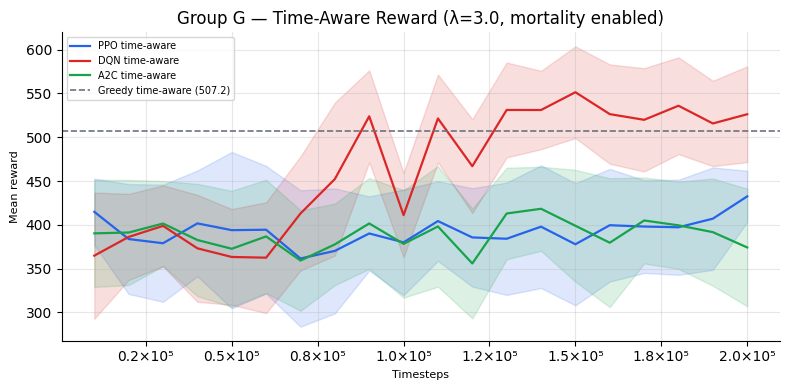

saved G_learning_curves


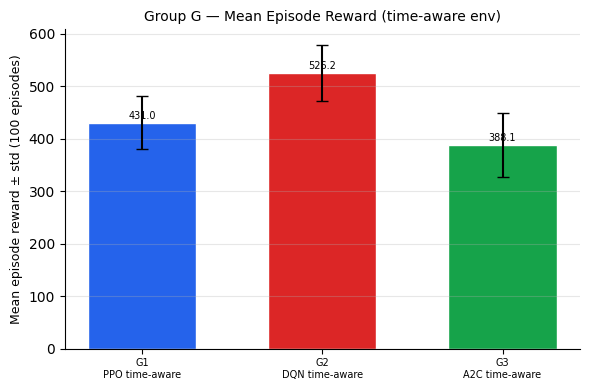

saved G_reward_bar


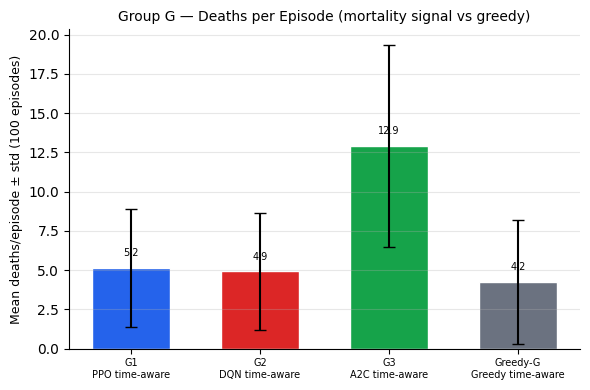

saved G_deaths_bar


In [ ]:
#  Group G: Time-Aware Reward with Critical-Patient Mortality

GROUP_G = ["G1", "G2", "G3"]
trained_G = {}
for eid in GROUP_G:
    trained_G[eid] = run_experiment(eid)   # loads from disk — no retraining
    result = evaluate_model(trained_G[eid], eid)
    store(eid, result)
    print(f"  {eid}: reward={result['mean_reward']:.2f} ± {result['std_reward']:.2f}"
          f"  admitted={result['mean_admitted']:.1f}"
          f"  deaths/ep={result['mean_deaths']:.1f} ± {result['std_deaths']:.1f}")

#  Greedy baseline for Group G environment
greedy_G = evaluate_greedy(
    arrival_rate=3.0,
    wait_time_aware=True,
    max_wait_crit_steps=6,
)
print(f"\nGreedy (time-aware, seed=99):")
print(f"  reward={greedy_G['mean_reward']:.2f} ± {greedy_G['std_reward']:.2f}"
      f"  admitted={greedy_G['mean_admitted']:.1f}"
      f"  deaths/ep={greedy_G['mean_deaths']:.1f} ± {greedy_G['std_deaths']:.1f}")

# Store greedy_G in ALL_RESULTS so the deaths bar can include it
ALL_RESULTS["Greedy-G"] = {
    "label":      "Greedy time-aware",
    "reward":     {"mean": greedy_G["mean_reward"],    "std": greedy_G["std_reward"]},
    "admitted":   {"mean": greedy_G["mean_admitted"],  "std": greedy_G["std_admitted"]},
    "redirected": {"mean": greedy_G["mean_redirected"],"std": greedy_G["std_redirected"]},
    "unserved":   {"mean": greedy_G["mean_unserved"],  "std": greedy_G["std_unserved"]},
    "deaths":     {"mean": greedy_G["mean_deaths"],    "std": greedy_G["std_deaths"]},
}

#  Chart 1: Reward comparison (G1/G2/G3 + greedy reference line)
fig, ax = plt.subplots(figsize=(8, 4))
for eid, col in zip(GROUP_G, GROUP_COLORS["G"]):
    _, _, _, _, lbl = EXPERIMENTS[eid]
    plot_curve(eid, lbl.split(" ", 1)[1], ax=ax, color=col)
ax.axhline(greedy_G["mean_reward"], color="#6B7280", linestyle="--",
           lw=1.2, label=f"Greedy time-aware ({greedy_G['mean_reward']:.1f})")
ax.legend(fontsize=7)
ax.set_title("Group G — Time-Aware Reward (λ=3.0, mortality enabled)")
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(FIGURES / f"G_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved G_learning_curves")

bar_chart(GROUP_G, ALL_RESULTS, "reward",
          "Group G — Mean Episode Reward (time-aware env)",
          "G_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)",
          colors=GROUP_COLORS["G"])

#  Chart 2: Deaths/ep — does the mortality penalty reduce patient deaths?
g_plus_greedy = GROUP_G + ["Greedy-G"]
deaths_colors  = GROUP_COLORS["G"] + ["#6B7280"]

bar_chart(g_plus_greedy, ALL_RESULTS, "deaths",
          "Group G — Deaths per Episode (mortality signal vs greedy)",
          "G_deaths_bar",
          ylabel="Mean deaths/episode ± std (100 episodes)",
          colors=deaths_colors)


  [H1]  Loading saved model (PPO) ← output/models/H1/best_model.zip
  H1: reward=152.16 ± 57.91  overflow=388.4
  [H2]  Loading saved model (DQN) ← output/models/H2/best_model.zip
  H2: reward=252.69 ± 74.85  overflow=383.9
  [H3]  Loading saved model (A2C) ← output/models/H3/best_model.zip
  H3: reward=18.54 ± 107.33  overflow=418.1
  [H4]  Loading saved model (PPO) ← output/models/H4/best_model.zip
  H4: reward=-421.93 ± 130.05  overflow=690.6
  [H5]  Loading saved model (DQN) ← output/models/H5/best_model.zip
  H5: reward=-221.57 ± 108.08  overflow=662.3

Overflow reduction vs baseline (λ=3.0):
  H1 vs A1: 6.4 fewer overflows/ep (388.4 vs 394.9)
  H2 vs A2: 4.2 more overflows/ep (383.9 vs 379.7)
  H3 vs A3: 0.0 fewer overflows/ep (418.1 vs 418.1)

Overflow reduction vs surge (λ=4.5):
  H4 vs B4: 24.4 more overflows/ep (690.6 vs 666.2)
  H5 vs B5: 11.1 fewer overflows/ep (662.3 vs 673.4)


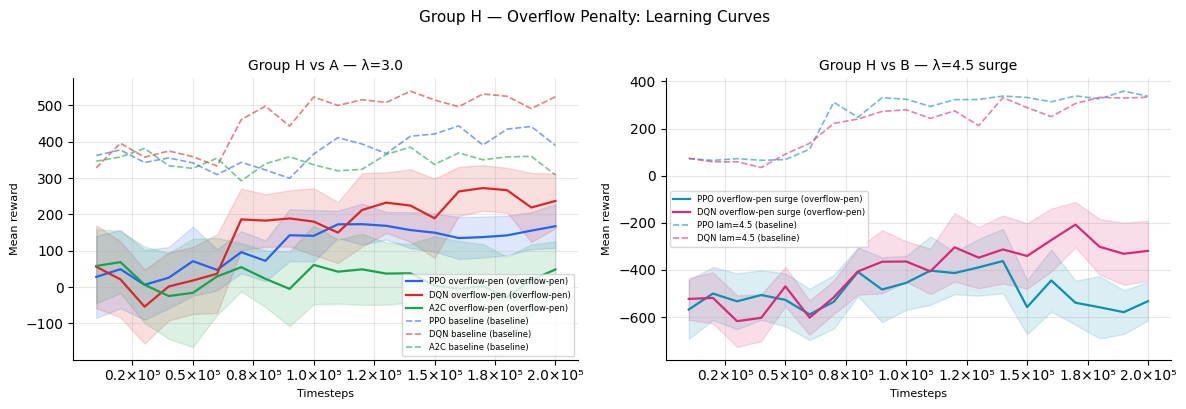

saved H_learning_curves


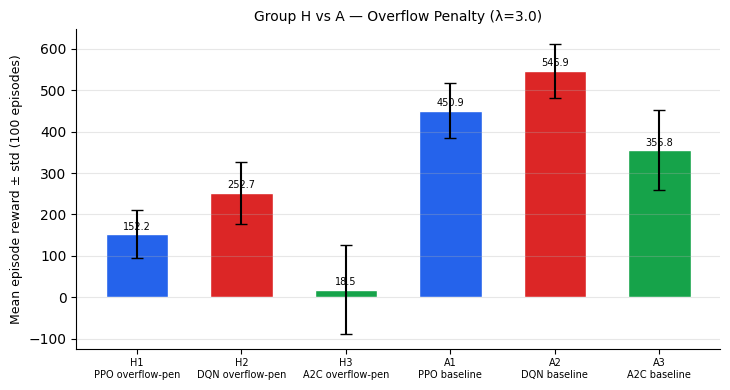

saved H_vs_A_reward_bar


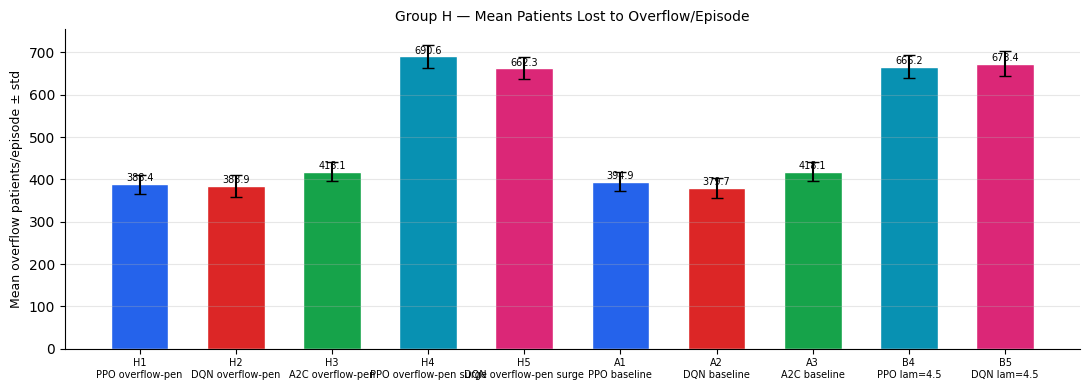

saved H_overflow_bar


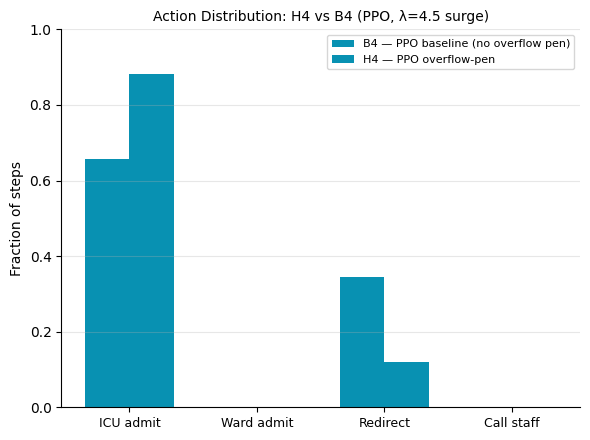

H4 vs B4 action-share deltas (H4 − B4):
  ICU admit:  +0.224
  Ward admit: +0.000
  Redirect:   -0.224
  Call staff: +0.000
  → H4 redirects LESS than B4 and admits MORE (ICU and/or ward):
    the overflow penalty is pushing the agent toward more aggressive
    admission instead of redirecting, consistent with mechanism (c).
    This is consistent with overflow getting WORSE for H4 (see above):
    redirect always clears a patient from the queue immediately, so
    redirecting less while admitting into an already-saturated system
    leaves more patients queued and exposed to overflow, not fewer.


In [ ]:
#  Group H: Overflow Penalty Ablation

GROUP_H = ["H1", "H2", "H3", "H4", "H5"]
trained_H = {}
for eid in GROUP_H:
    trained_H[eid] = run_experiment(eid)
    result = evaluate_model(trained_H[eid], eid)
    store(eid, result)
    print(f"  {eid}: reward={result['mean_reward']:.2f} ± {result['std_reward']:.2f}"
          f"  overflow={result['mean_overflow']:.1f}")

#  Overflow reduction vs comparable groups
print("\nOverflow reduction vs baseline (λ=3.0):")
for h, a in [("H1","A1"), ("H2","A2"), ("H3","A3")]:
    if h in ALL_RESULTS and a in ALL_RESULTS:
        h_ov = ALL_RESULTS[h]["overflow"]["mean"]
        a_ov = ALL_RESULTS[a]["overflow"]["mean"]
        delta = a_ov - h_ov   # positive = H has fewer overflows than baseline
        direction = "fewer" if delta >= 0 else "more"
        print(f"  {h} vs {a}: {abs(delta):.1f} {direction} overflows/ep ({h_ov:.1f} vs {a_ov:.1f})")

print("\nOverflow reduction vs surge (λ=4.5):")
for h, b in [("H4","B4"), ("H5","B5")]:
    if h in ALL_RESULTS and b in ALL_RESULTS:
        h_ov = ALL_RESULTS[h]["overflow"]["mean"]
        b_ov = ALL_RESULTS[b]["overflow"]["mean"]
        delta = b_ov - h_ov   # positive = H has fewer overflows than baseline
        direction = "fewer" if delta >= 0 else "more"
        print(f"  {h} vs {b}: {abs(delta):.1f} {direction} overflows/ep ({h_ov:.1f} vs {b_ov:.1f})")

#  Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for eid, col in zip(["H1","H2","H3"], GROUP_COLORS["H"][:3]):
    _, _, _, _, lbl = EXPERIMENTS[eid]
    plot_curve(eid, lbl.split(" ",1)[1] + " (overflow-pen)", ax=ax, color=col)
for eid, col in zip(["A1","A2","A3"], GROUP_COLORS["A"]):
    if (MODELS / eid / "evaluations.npz").exists():
        d = np.load(MODELS / eid / "evaluations.npz")
        ax.plot(d["timesteps"], d["results"].mean(1),
                linestyle="--", color=col, lw=1.2, alpha=0.6,
                label=EXPERIMENTS[eid][4].split(" ",1)[1]+" (baseline)")
ax.set_title("Group H vs A — λ=3.0", fontsize=10)
ax.legend(fontsize=6); ax.grid(alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

ax = axes[1]
for eid, col in zip(["H4","H5"], GROUP_COLORS["H"][3:5]):
    _, _, _, _, lbl = EXPERIMENTS[eid]
    plot_curve(eid, lbl.split(" ",1)[1]+" (overflow-pen)", ax=ax, color=col)
for eid, col in zip(["B4","B5"], GROUP_COLORS["B"][3:5]):
    if (MODELS / eid / "evaluations.npz").exists():
        d = np.load(MODELS / eid / "evaluations.npz")
        ax.plot(d["timesteps"], d["results"].mean(1),
                linestyle="--", color=col, lw=1.2, alpha=0.6,
                label=EXPERIMENTS[eid][4].split(" ",1)[1]+" (baseline)")
ax.set_title("Group H vs B — λ=4.5 surge", fontsize=10)
ax.legend(fontsize=6); ax.grid(alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Group H — Overflow Penalty: Learning Curves", fontsize=11, y=1.01)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(FIGURES / f"H_learning_curves.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved H_learning_curves")

#  Reward bar chart
bar_chart(["H1","H2","H3","A1","A2","A3"], ALL_RESULTS, "reward",
          "Group H vs A — Overflow Penalty (λ=3.0)", "H_vs_A_reward_bar",
          ylabel="Mean episode reward ± std (100 episodes)",
          colors=GROUP_COLORS["H"][:3] + GROUP_COLORS["A"])

#  Overflow count bar chart (key new metric)
bar_chart(GROUP_H + ["A1","A2","A3","B4","B5"], ALL_RESULTS, "overflow",
          "Group H — Mean Patients Lost to Overflow/Episode", "H_overflow_bar",
          ylabel="Mean overflow patients/episode ± std",
          colors=GROUP_COLORS["H"] + GROUP_COLORS["A"] + GROUP_COLORS["B"][3:5])

#  Action distribution: H4 (overflow-aware) vs B4 (baseline) at surge

if "H4" in trained_H and "B4" in trained:
    h4_dist = action_dist(trained_H["H4"], "H4")
    b4_dist = action_dist(trained["B4"], "B4")

    fig, ax = plt.subplots(figsize=(6, 4.5))
    x = np.arange(4)
    w = 0.35
    ax.bar(x - w/2, b4_dist, width=w, label="B4 — PPO baseline (no overflow pen)",
           color=GROUP_COLORS["B"][3])
    ax.bar(x + w/2, h4_dist, width=w, label="H4 — PPO overflow-pen",
           color=GROUP_COLORS["H"][3])
    ax.set_xticks(x)
    ax.set_xticklabels(action_labels, fontsize=9)
    ax.set_ylabel("Fraction of steps")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.set_title("Action Distribution: H4 vs B4 (PPO, λ=4.5 surge)", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(FIGURES / f"H4_vs_B4_action_distribution.{ext}", bbox_inches="tight", dpi=150)
    plt.show()

    redirect_delta = h4_dist[2] - b4_dist[2]
    icu_delta      = h4_dist[0] - b4_dist[0]
    ward_delta     = h4_dist[1] - b4_dist[1]
    print(f"H4 vs B4 action-share deltas (H4 − B4):")
    print(f"  ICU admit:  {icu_delta:+.3f}")
    print(f"  Ward admit: {ward_delta:+.3f}")
    print(f"  Redirect:   {redirect_delta:+.3f}")
    print(f"  Call staff: {(h4_dist[3]-b4_dist[3]):+.3f}")
    if redirect_delta > 0.02:
        print("  → H4 redirects more than B4: the overflow penalty is shifting")
        print("    behaviour toward earlier redirection, consistent with mechanism (a).")
    elif redirect_delta < -0.02 and (icu_delta > 0.02 or ward_delta > 0.02):
        print("  → H4 redirects LESS than B4 and admits MORE (ICU and/or ward):")
        print("    the overflow penalty is pushing the agent toward more aggressive")
        print("    admission instead of redirecting, consistent with mechanism (c).")
        print("    This is consistent with overflow getting WORSE for H4 (see above):")
        print("    redirect always clears a patient from the queue immediately, so")
        print("    redirecting less while admitting into an already-saturated system")
        print("    leaves more patients queued and exposed to overflow, not fewer.")
    elif icu_delta < -0.02 or ward_delta < -0.02:
        print("  → H4 admits less (ICU and/or ward) without redirecting more: the")
        print("    agent is hesitating near full queues without a clear alternative")
        print("    strategy, consistent with mechanism (b).")
    else:
        print("  → No meaningful shift in action distribution: H4's policy is close")
        print("    to indistinguishable from B4's, consistent with overflow_penalty=1.0")
        print("    being too small to change behaviour (see the penalty-scale sweep below).")
else:
    print("H4 or B4 model not available in memory — run Cells 9 and 26 first.")


─── Group H Robustness: H4 (PPO, overflow_penalty=1.0, λ=4.5) ───
  [H4_multiseed_seed42]  Loading saved model (PPO) ← output/models/H4_multiseed_seed42/best_model.zip
  seed=42: reward=-409.65  unserved=2021.2
  [H4_multiseed_seed123]  Loading saved model (PPO) ← output/models/H4_multiseed_seed123/best_model.zip
  seed=123: reward=-542.50  unserved=2536.9
  [H4_multiseed_seed777]  Loading saved model (PPO) ← output/models/H4_multiseed_seed777/best_model.zip
  seed=777: reward=-365.46  unserved=1861.5
  H4 → reward: -439.21 ± 75.24  unserved: 2139.9 ± 288.2

─── Group H Robustness: H5 (DQN, overflow_penalty=1.0, λ=4.5) ───
  [H5_multiseed_seed42]  Loading saved model (DQN) ← output/models/H5_multiseed_seed42/best_model.zip
  seed=42: reward=-195.75  unserved=1263.9
  [H5_multiseed_seed123]  Loading saved model (DQN) ← output/models/H5_multiseed_seed123/best_model.zip
  seed=123: reward=-290.27  unserved=1908.6
  [H5_multiseed_seed777]  Loading saved model (DQN) ← output/models/H5_multi

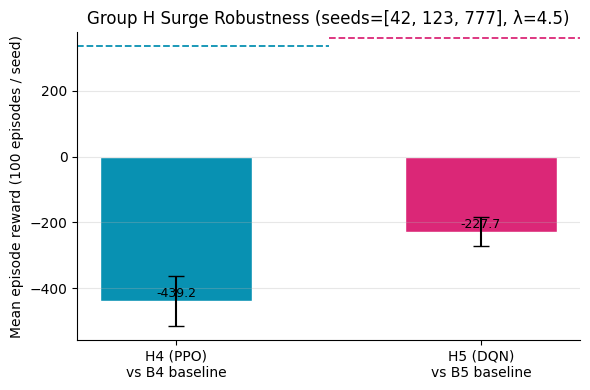

saved H_surge_multiseed_robustness


In [ ]:
#  Group H Robustness Check: Reseeding H4/H5

print("─── Group H Robustness: H4 (PPO, overflow_penalty=1.0, λ=4.5) ───")
h4_rewards, h4_unserved = run_multi_seed(
    "PPO", dict(arrival_rate=4.5, overflow_penalty=1.0),
    MULTI_SEEDS, "H4_multiseed")
print(f"  H4 → reward: {np.mean(h4_rewards):.2f} ± {np.std(h4_rewards):.2f}"
      f"  unserved: {np.mean(h4_unserved):.1f} ± {np.std(h4_unserved):.1f}")

print("\n─── Group H Robustness: H5 (DQN, overflow_penalty=1.0, λ=4.5) ───")
h5_rewards, h5_unserved = run_multi_seed(
    "DQN", dict(arrival_rate=4.5, overflow_penalty=1.0),
    MULTI_SEEDS, "H5_multiseed")
print(f"  H5 → reward: {np.mean(h5_rewards):.2f} ± {np.std(h5_rewards):.2f}"
      f"  unserved: {np.mean(h5_unserved):.1f} ± {np.std(h5_unserved):.1f}")

# Compare against the single-seed (seed=42) numbers already in ALL_RESULTS,
b4_mean = ALL_RESULTS.get("B4", {}).get("reward", {}).get("mean")
b5_mean = ALL_RESULTS.get("B5", {}).get("reward", {}).get("mean")
h4_single = ALL_RESULTS.get("H4", {}).get("reward", {}).get("mean")
h5_single = ALL_RESULTS.get("H5", {}).get("reward", {}).get("mean")

print("\n─── Single-seed vs multi-seed comparison ───")
print(f"  H4 single-seed (seed=42): {h4_single:.2f}   multi-seed mean±std: "
      f"{np.mean(h4_rewards):.2f} ± {np.std(h4_rewards):.2f}   B4 baseline: {b4_mean:.2f}")
print(f"  H5 single-seed (seed=42): {h5_single:.2f}   multi-seed mean±std: "
      f"{np.mean(h5_rewards):.2f} ± {np.std(h5_rewards):.2f}   B5 baseline: {b5_mean:.2f}")

# Summary bar chart: H4/H5 multi-seed mean ± std vs B4/B5 single-run reference
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
means_h = [np.mean(h4_rewards), np.mean(h5_rewards)]
stds_h  = [np.std(h4_rewards),  np.std(h5_rewards)]
bars = ax.bar(x, means_h, yerr=stds_h, color=[GROUP_COLORS["H"][3], GROUP_COLORS["H"][4]],
              capsize=6, edgecolor="white", width=0.5, label="H (3 seeds)")
for bar, m in zip(bars, means_h):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"{m:.1f}", ha="center", va="bottom", fontsize=9)
if b4_mean is not None:
    ax.axhline(b4_mean, xmin=0.0, xmax=0.5, color=GROUP_COLORS["B"][3], linestyle="--", lw=1.3)
if b5_mean is not None:
    ax.axhline(b5_mean, xmin=0.5, xmax=1.0, color=GROUP_COLORS["B"][4], linestyle="--", lw=1.3)
ax.set_xticks(x)
ax.set_xticklabels(["H4 (PPO)\nvs B4 baseline", "H5 (DQN)\nvs B5 baseline"])
ax.set_ylabel("Mean episode reward (100 episodes / seed)")
ax.set_title(f"Group H Surge Robustness (seeds={MULTI_SEEDS}, λ=4.5)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(FIGURES / f"H_surge_multiseed_robustness.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved H_surge_multiseed_robustness")


  [Hsweep_pen1]  Loading saved model ← output/models/Hsweep_pen1/best_model.zip
  overflow_penalty=   1: reward=158.31 ± 52.48   overflow/ep=386.5 ± 24.8
  [Hsweep_pen5]  Loading saved model ← output/models/Hsweep_pen5/best_model.zip
  overflow_penalty=   5: reward=-1330.32 ± 169.99   overflow/ep=418.1 ± 22.4
  [Hsweep_pen10]  Loading saved model ← output/models/Hsweep_pen10/best_model.zip
  overflow_penalty=  10: reward=-3174.77 ± 280.94   overflow/ep=392.0 ± 24.3

Reference — A1 (overflow_penalty=0.0): reward=450.91, overflow/ep=394.9


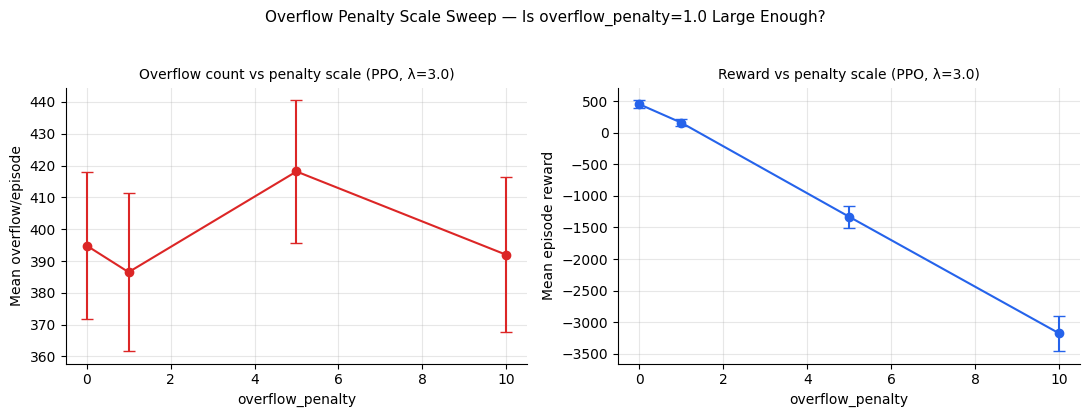

saved overflow_penalty_sweep

Overflow reduction at penalty=1:  +8.4 (vs A1 baseline)
Overflow reduction at penalty=10: +2.9 (vs A1 baseline)
→ Scaling the penalty up did not meaningfully change overflow counts: the
  weak effect in Group H is not purely a scale issue.


In [ ]:
#  Overflow Penalty Scale Sweep

OVERFLOW_SWEEP = [1.0, 5.0, 10.0]
import json
sweep_results = {}

for pen in OVERFLOW_SWEEP:
    tag = f"Hsweep_pen{pen:.0f}"
    env_kwargs = dict(arrival_rate=3.0, overflow_penalty=pen)
    model_dir  = MODELS / tag
    model_dir.mkdir(parents=True, exist_ok=True)
    saved_path = model_dir / "best_model.zip"
    meta_path  = model_dir / "meta.json"

    loaded = False
    if saved_path.exists() and meta_path.exists():
        with open(meta_path) as mf:
            meta = json.load(mf)
        if meta.get("overflow_penalty") == pen and meta.get("algo_name") == "PPO":
            print(f"  [{tag}]  Loading saved model ← {saved_path}")
            train_env = make_env(env_kwargs, SEED)
            model = PPO.load(str(saved_path), env=train_env)
            loaded = True

    if not loaded:
        print(f"  [{tag}]  Training PPO, overflow_penalty={pen}")
        train_env = make_env(env_kwargs, SEED)
        eval_env  = make_env(env_kwargs, SEED + 1)
        hp = dict(ALGO_DEFAULTS["PPO"])
        model = PPO(
            policy        = "MlpPolicy",
            env           = train_env,
            seed          = SEED,
            verbose       = 0,
            policy_kwargs = {"net_arch": [64, 64]},
            **hp,
        )
        cb = EvalCallback(
            eval_env,
            best_model_save_path = str(model_dir),
            log_path             = str(model_dir),
            eval_freq            = 10_000,
            n_eval_episodes      = 20,
            deterministic        = True,
            verbose              = 0,
        )
        model.learn(total_timesteps=TIMESTEPS, callback=cb, progress_bar=True)
        with open(meta_path, "w") as mf:
            json.dump({"algo_name": "PPO", "overflow_penalty": pen,
                       "exp_id": tag, "timesteps": TIMESTEPS}, mf, indent=2)

    # Evaluate on 100 episodes, seed=99 (matching evaluate_model() throughout)
    env_eval = HospitalEnv(**env_kwargs)
    rng = np.random.default_rng(99)
    ep_rewards, ep_overflow = [], []
    for _ in range(100):
        obs, _ = env_eval.reset(seed=int(rng.integers(0, 2**31)))
        ep_r = ep_ov = 0
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, info = env_eval.step(int(action))
            ep_r  += r
            ep_ov += info.get("n_overflow", 0)
        ep_rewards.append(ep_r)
        ep_overflow.append(ep_ov)

    sweep_results[pen] = {
        "reward_mean":   np.mean(ep_rewards),
        "reward_std":    np.std(ep_rewards),
        "overflow_mean": np.mean(ep_overflow),
        "overflow_std":  np.std(ep_overflow),
    }
    print(f"  overflow_penalty={pen:>4.0f}: reward={np.mean(ep_rewards):.2f} ± {np.std(ep_rewards):.2f}"
          f"   overflow/ep={np.mean(ep_overflow):.1f} ± {np.std(ep_overflow):.1f}")

# Reference: A1 (overflow_penalty=0.0) and H1 (overflow_penalty=1.0, already trained)
a1_overflow = ALL_RESULTS.get("A1", {}).get("overflow", {}).get("mean")
a1_reward   = ALL_RESULTS.get("A1", {}).get("reward",   {}).get("mean")
print(f"\nReference — A1 (overflow_penalty=0.0): reward={a1_reward:.2f}, overflow/ep={a1_overflow:.1f}")

# Plot: overflow/ep and reward as a function of overflow_penalty
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pens_plot = [0.0] + OVERFLOW_SWEEP
ov_means  = [a1_overflow] + [sweep_results[p]["overflow_mean"] for p in OVERFLOW_SWEEP]
ov_stds   = [ALL_RESULTS.get("A1", {}).get("overflow", {}).get("std", 0.0)] + \
            [sweep_results[p]["overflow_std"] for p in OVERFLOW_SWEEP]
rw_means  = [a1_reward] + [sweep_results[p]["reward_mean"] for p in OVERFLOW_SWEEP]
rw_stds   = [ALL_RESULTS.get("A1", {}).get("reward", {}).get("std", 0.0)] + \
            [sweep_results[p]["reward_std"] for p in OVERFLOW_SWEEP]

ax = axes[0]
ax.errorbar(pens_plot, ov_means, yerr=ov_stds, marker="o", color="#DC2626", capsize=4)
ax.set_xlabel("overflow_penalty")
ax.set_ylabel("Mean overflow/episode")
ax.set_title("Overflow count vs penalty scale (PPO, λ=3.0)", fontsize=10)
ax.grid(alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

ax = axes[1]
ax.errorbar(pens_plot, rw_means, yerr=rw_stds, marker="o", color="#2563EB", capsize=4)
ax.set_xlabel("overflow_penalty")
ax.set_ylabel("Mean episode reward")
ax.set_title("Reward vs penalty scale (PPO, λ=3.0)", fontsize=10)
ax.grid(alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Overflow Penalty Scale Sweep — Is overflow_penalty=1.0 Large Enough?", fontsize=11, y=1.03)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(FIGURES / f"overflow_penalty_sweep.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved overflow_penalty_sweep")

overflow_drop_at_10 = a1_overflow - sweep_results[10.0]["overflow_mean"]
overflow_drop_at_1  = a1_overflow - sweep_results[1.0]["overflow_mean"]
print(f"\nOverflow reduction at penalty=1:  {overflow_drop_at_1:+.1f} (vs A1 baseline)")
print(f"Overflow reduction at penalty=10: {overflow_drop_at_10:+.1f} (vs A1 baseline)")
if abs(overflow_drop_at_10) > 2 * abs(overflow_drop_at_1) + 1e-6:
    print("→ Scaling the penalty up materially increases its effect: overflow_penalty=1.0")
    print("  was indeed too small relative to the queue-penalty scale, confirming the")
    print("  reward-scale concern above.")
else:
    print("→ Scaling the penalty up did not meaningfully change overflow counts: the")
    print("  weak effect in Group H is not purely a scale issue.")


---

## Groups I, J, K : Follow-Up Experiments

- **Group I** — does training A2C on 8 parallel environments fix its collapse?
- **Group J** — is the flat λ=6.0 result a real policy-quality limit, or just a capacity ceiling?
- **Group K** — does tuning DQN's network/hyperparameters move it, the way Groups E/F tested for PPO?


### Group I — A2C with parallel environments (`n_envs=8`)


  [I1]  Loading saved model (A2C, n_envs=8)

A3 (n_envs=1): reward = 355.76
I1 (n_envs=8): reward = 355.76
Delta = +0.00
-> No meaningful change. The single-environment bottleneck isn't the whole story.
  [A3]  Loading saved model (A2C) ← output/models/A3/best_model.zip

Action distribution:
  ICU admit     A3: 100.0%   I1: 100.0%
  Ward admit    A3:   0.0%   I1:   0.0%
  Redirect      A3:   0.0%   I1:   0.0%
  Call staff    A3:   0.0%   I1:   0.0%


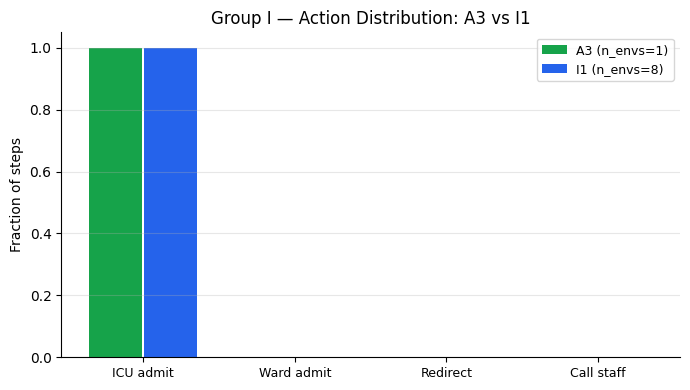

saved I_action_distribution


In [ ]:
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv

N_ENVS_I = 8


def make_a2c_vec_env(env_kwargs, n_envs=N_ENVS_I):
    def _init():
        return Monitor(HospitalEnv(**env_kwargs))
    vec_cls = SubprocVecEnv if n_envs > 1 else DummyVecEnv
    return vec_cls([_init for _ in range(n_envs)])


def run_experiment_vec(exp_id, env_kwargs, n_envs, timesteps=TIMESTEPS, seed=SEED):
    """Same save/load/meta.json pattern as run_experiment(), but trains on a
    VecEnv. Only used for Group I, since it's the one experiment that needs
    a vectorized training env instead of a single one."""
    import json as _json

    model_dir = MODELS / exp_id
    model_dir.mkdir(parents=True, exist_ok=True)
    saved_path = model_dir / "best_model.zip"
    meta_path = model_dir / "meta.json"
    eval_env = make_env(env_kwargs, seed + 1)

    if saved_path.exists() and meta_path.exists():
        meta = _json.loads(meta_path.read_text())
        if meta.get("exp_id") == exp_id and meta.get("n_envs") == n_envs:
            print(f"  [{exp_id}]  Loading saved model (A2C, n_envs={n_envs})")
            return A2C.load(str(saved_path), env=eval_env)

    print(f"  [{exp_id}]  Training A2C, n_envs={n_envs}, {timesteps:,} steps")
    train_env = make_a2c_vec_env(env_kwargs, n_envs=n_envs)
    model = A2C(
        policy="MlpPolicy",
        env=train_env,
        seed=seed,
        verbose=0,
        tensorboard_log=str(TB_LOGS),
        policy_kwargs={"net_arch": [64, 64]},
        **ALGO_DEFAULTS["A2C"],
    )
    cb = EvalCallback(
        eval_env,
        best_model_save_path=str(model_dir),
        log_path=str(model_dir),
        eval_freq=max(10_000 // n_envs, 1000),
        n_eval_episodes=10,
        deterministic=True,
        verbose=0,
    )
    model.learn(total_timesteps=timesteps, callback=cb, progress_bar=True)
    train_env.close()

    meta_path.write_text(_json.dumps(
        {"exp_id": exp_id, "algo_name": "A2C", "n_envs": n_envs,
         "seed": seed, "timesteps": timesteps}, indent=2))
    return A2C.load(str(model_dir / "best_model.zip"), env=eval_env)


EXPERIMENTS["I1"] = ("A2C", dict(arrival_rate=3.0), {}, "I", "I1 A2C n_envs=8")
GROUP_COLORS["I"] = ["#16A34A", "#2563EB"]

model_I1 = run_experiment_vec("I1", dict(arrival_rate=3.0), n_envs=N_ENVS_I)
result_I1 = evaluate_model(model_I1, "I1")
store("I1", result_I1)

reward_A3 = ALL_RESULTS["A3"]["reward"]["mean"]
reward_I1 = result_I1["mean_reward"]
delta_I1 = reward_I1 - reward_A3

print(f"\nA3 (n_envs=1): reward = {reward_A3:.2f}")
print(f"I1 (n_envs=8): reward = {reward_I1:.2f}")
print(f"Delta = {delta_I1:+.2f}")
if delta_I1 > 50:
    print("-> Parallel environments meaningfully improved A2C.")
else:
    print("-> No meaningful change. The single-environment bottleneck isn't the whole story.")

dist_A3 = action_dist(run_experiment("A3"), "A3")
dist_I1 = action_dist(model_I1, "I1")

print("\nAction distribution:")
for name, a3v, i1v in zip(action_labels, dist_A3, dist_I1):
    print(f"  {name:12s}  A3: {a3v:6.1%}   I1: {i1v:6.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(4)
ax.bar(x - 0.18, dist_A3, 0.35, label="A3 (n_envs=1)", color=GROUP_COLORS["I"][0])
ax.bar(x + 0.18, dist_I1, 0.35, label="I1 (n_envs=8)", color=GROUP_COLORS["I"][1])
ax.set_xticks(x)
ax.set_xticklabels(action_labels, fontsize=9)
ax.set_ylabel("Fraction of steps")
ax.set_title("Group I — Action Distribution: A3 vs I1")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(FIGURES / f"I_action_distribution.{ext}", bbox_inches="tight", dpi=150)
plt.show()
print("saved I_action_distribution")


### Group J — high capacity at λ=6.0


  [J1]  Loading saved model (PPO) ← output/models/J1/best_model.zip
  J1: reward=239.59 +/- 88.92  crit_unserved=2970.7
  [J2]  Loading saved model (DQN) ← output/models/J2/best_model.zip
  J2: reward=303.91 +/- 66.37  crit_unserved=2907.5
  [J3]  Loading saved model (A2C) ← output/models/J3/best_model.zip
  J3: reward=74.95 +/- 68.77  crit_unserved=3077.1

Greedy (lam=6.0, high-cap): reward=286.86  crit_unserved=2905.6

Range (max − min) of crit_unserved across algorithms:
  Default capacity (B7/B8/B9): 62.7
  High capacity   (J1/J2/J3):  169.6
-> Algorithms separate out once the bed ceiling is raised.


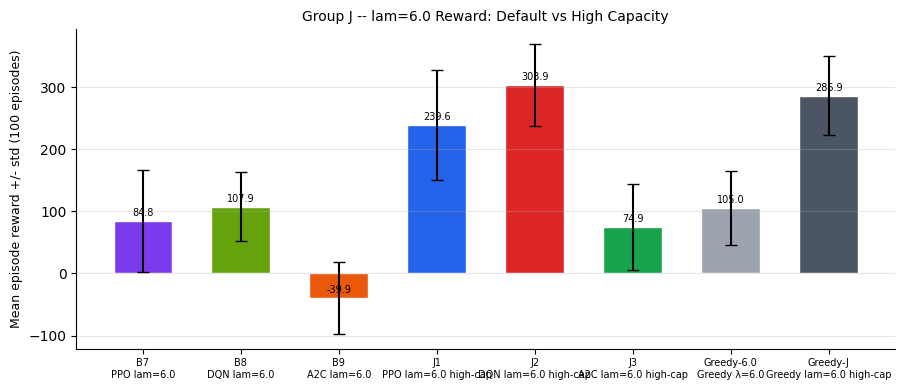

saved J_reward_bar


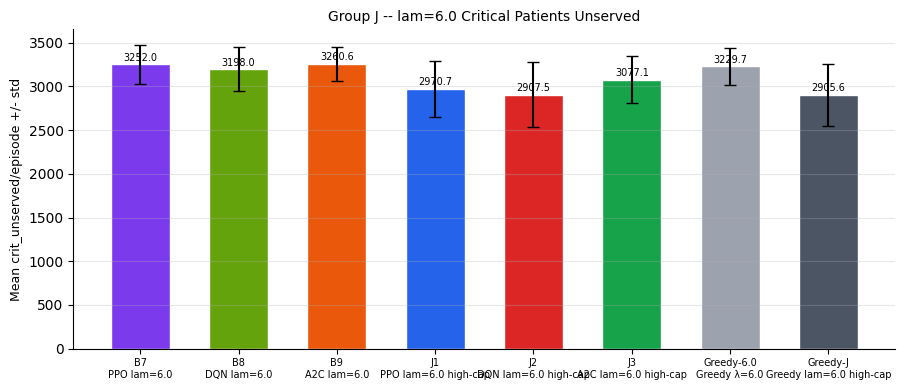

saved J_unserved_bar


In [ ]:
EXPERIMENTS["J1"] = ("PPO", dict(arrival_rate=6.0, high_cap=True), {}, "J", "J1 PPO lam=6.0 high-cap")
EXPERIMENTS["J2"] = ("DQN", dict(arrival_rate=6.0, high_cap=True), {}, "J", "J2 DQN lam=6.0 high-cap")
EXPERIMENTS["J3"] = ("A2C", dict(arrival_rate=6.0, high_cap=True), {}, "J", "J3 A2C lam=6.0 high-cap")
GROUP_COLORS["J"] = ["#2563EB", "#DC2626", "#16A34A"]
GROUP_J = ["J1", "J2", "J3"]

for eid in GROUP_J:
    model = run_experiment(eid)
    result = evaluate_model(model, eid)
    store(eid, result)
    print(f"  {eid}: reward={result['mean_reward']:.2f} +/- {result['std_reward']:.2f}"
          f"  crit_unserved={result['mean_unserved']:.1f}")

greedy_J = evaluate_greedy(arrival_rate=6.0, high_cap=True)
ALL_RESULTS["Greedy-J"] = {
    "label": "Greedy lam=6.0 high-cap",
    "reward": {"mean": greedy_J["mean_reward"], "std": greedy_J["std_reward"]},
    "admitted": {"mean": greedy_J["mean_admitted"], "std": greedy_J["std_admitted"]},
    "redirected": {"mean": greedy_J["mean_redirected"], "std": greedy_J["std_redirected"]},
    "unserved": {"mean": greedy_J["mean_unserved"], "std": greedy_J["std_unserved"]},
    "deaths": {"mean": 0.0, "std": 0.0},
    "overflow": {"mean": 0.0, "std": 0.0},
    "overflow_crit": {"mean": 0.0, "std": 0.0},
}
print(f"\nGreedy (lam=6.0, high-cap): reward={greedy_J['mean_reward']:.2f}"
      f"  crit_unserved={greedy_J['mean_unserved']:.1f}")

default_ids = ["B7", "B8", "B9"]
unserved_default = [ALL_RESULTS[e]["unserved"]["mean"] for e in default_ids if e in ALL_RESULTS]
unserved_highcap = [ALL_RESULTS[e]["unserved"]["mean"] for e in GROUP_J]
spread_default = max(unserved_default) - min(unserved_default) if unserved_default else 0
spread_highcap = max(unserved_highcap) - min(unserved_highcap)

print(f"\nRange (max − min) of crit_unserved across algorithms:")
print(f"  Default capacity (B7/B8/B9): {spread_default:.1f}")
print(f"  High capacity   (J1/J2/J3):  {spread_highcap:.1f}")
if spread_highcap > spread_default * 1.5:
    print("-> Algorithms separate out once the bed ceiling is raised.")
else:
    print("-> Algorithms remain similarly bottlenecked even at higher capacity.")

bar_chart(["B7", "B8", "B9", "J1", "J2", "J3", "Greedy-6.0", "Greedy-J"],
          ALL_RESULTS, "reward",
          "Group J -- lam=6.0 Reward: Default vs High Capacity", "J_reward_bar",
          ylabel="Mean episode reward +/- std (100 episodes)",
          colors=GROUP_COLORS["B"][6:9] + GROUP_COLORS["J"] + ["#9CA3AF", "#4B5563"])

bar_chart(["B7", "B8", "B9", "J1", "J2", "J3", "Greedy-6.0", "Greedy-J"],
          ALL_RESULTS, "unserved",
          "Group J -- lam=6.0 Critical Patients Unserved", "J_unserved_bar",
          ylabel="Mean crit_unserved/episode +/- std",
          colors=GROUP_COLORS["B"][6:9] + GROUP_COLORS["J"] + ["#9CA3AF", "#4B5563"])


### Group K : DQN network architecture and hyperparameter sensitivity

Added after Groups A-H as a deliberate follow-up: Groups E/F only tested PPO's architecture and hyperparameters, so this closes that gap for DQN specifically.


  [K1]  Loading saved model (DQN) ← output/models/K1/best_model.zip
  K1: reward=521.94 +/- 64.72
  [K2]  Loading saved model (DQN) ← output/models/K2/best_model.zip
  K2: reward=540.39 +/- 60.62
  [K3]  Loading saved model (DQN) ← output/models/K3/best_model.zip
  K3: reward=534.65 +/- 63.25
  [K4]  Loading saved model (DQN) ← output/models/K4/best_model.zip
  K4: reward=526.75 +/- 65.61
  [K5]  Loading saved model (DQN) ← output/models/K5/best_model.zip
  K5: reward=545.97 +/- 60.87
  [K6]  Loading saved model (DQN) ← output/models/K6/best_model.zip
  K6: reward=550.55 +/- 56.49

Reference -- A2 (DQN, 64x64, default): reward=546.92
Best Group K variant -- K6 (DQN buffer=200k): reward=550.55
Delta vs A2 = +3.63
-> No meaningful change -- A2's defaults are already close to optimal,
   mirroring the Group E/F finding for PPO.


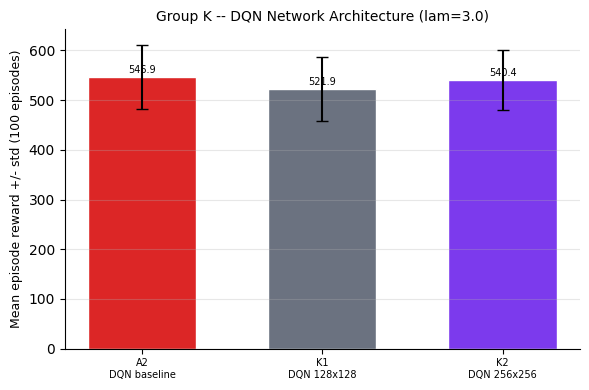

saved K_architecture_bar


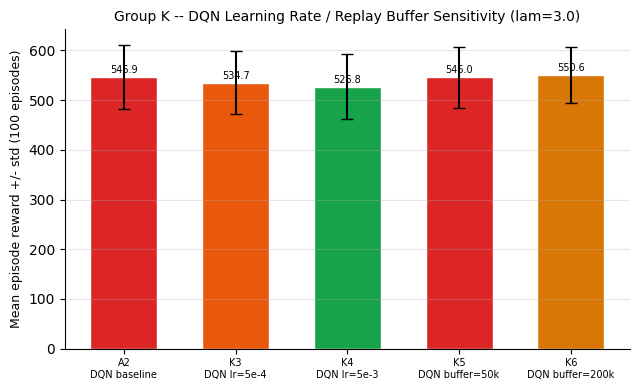

saved K_hp_bar


In [ ]:
EXPERIMENTS["K1"] = ("DQN", dict(arrival_rate=3.0), {"net_arch": [128, 128]}, "K", "K1 DQN 128x128")
EXPERIMENTS["K2"] = ("DQN", dict(arrival_rate=3.0), {"net_arch": [256, 256]}, "K", "K2 DQN 256x256")
EXPERIMENTS["K3"] = ("DQN", dict(arrival_rate=3.0), {"learning_rate": 5e-4}, "K", "K3 DQN lr=5e-4")
EXPERIMENTS["K4"] = ("DQN", dict(arrival_rate=3.0), {"learning_rate": 5e-3}, "K", "K4 DQN lr=5e-3")
EXPERIMENTS["K5"] = ("DQN", dict(arrival_rate=3.0), {"buffer_size": 50_000}, "K", "K5 DQN buffer=50k")
EXPERIMENTS["K6"] = ("DQN", dict(arrival_rate=3.0), {"buffer_size": 200_000}, "K", "K6 DQN buffer=200k")
GROUP_COLORS["K"] = ["#6B7280", "#7C3AED", "#EA580C", "#16A34A", "#DC2626", "#D97706"]
GROUP_K = ["K1", "K2", "K3", "K4", "K5", "K6"]

for eid in GROUP_K:
    model = run_experiment(eid)
    result = evaluate_model(model, eid)
    store(eid, result)
    print(f"  {eid}: reward={result['mean_reward']:.2f} +/- {result['std_reward']:.2f}")

reward_A2 = ALL_RESULTS["A2"]["reward"]["mean"]
best_k = max(GROUP_K, key=lambda e: ALL_RESULTS[e]["reward"]["mean"])
delta_k = ALL_RESULTS[best_k]["reward"]["mean"] - reward_A2

print(f"\nReference -- A2 (DQN, 64x64, default): reward={reward_A2:.2f}")
print(f"Best Group K variant -- {best_k} ({ALL_RESULTS[best_k]['label']}): "
      f"reward={ALL_RESULTS[best_k]['reward']['mean']:.2f}")
print(f"Delta vs A2 = {delta_k:+.2f}")
if delta_k > 5:
    print("-> Meaningful improvement over default DQN.")
else:
    print("-> No meaningful change -- A2's defaults are already close to optimal,")
    print("   mirroring the Group E/F finding for PPO.")

bar_chart(["A2", "K1", "K2"], ALL_RESULTS, "reward",
          "Group K -- DQN Network Architecture (lam=3.0)", "K_architecture_bar",
          ylabel="Mean episode reward +/- std (100 episodes)",
          colors=["#DC2626"] + GROUP_COLORS["K"][:2])

bar_chart(["A2", "K3", "K4", "K5", "K6"], ALL_RESULTS, "reward",
          "Group K -- DQN Learning Rate / Replay Buffer Sensitivity (lam=3.0)", "K_hp_bar",
          ylabel="Mean episode reward +/- std (100 episodes)",
          colors=["#DC2626"] + GROUP_COLORS["K"][2:])


---

## Group L : Reward Redesign

Four targeted changes to the reward function, each motivated directly by a finding from Groups A-K: an idle-ward penalty (L1), an overflow/queue-penalty blend instead of stacking them (L2, also tested under surge), a stronger mortality penalty (L3), and a small grid of alternative reward weights (L4). All four are implemented as constructor parameters on `HospitalEnv`, default to off, so Groups A-K are reproduced unchanged.

The cell below trains/loads and evaluates all fourteen L conditions, then prints the same A1/A2/G1/G2/H1/H2 reference points used earlier for comparison. **Note on L4 vs. greedy comparison:** L4 trains under different reward weights than the rest of the notebook. To keep the comparison fair, the greedy policy is re-evaluated under each L4 weight grid at the end of this cell (`Greedy-L4_1`, `Greedy-L4_2`, `Greedy-L4_3`), so every L4 delta reported in the Conclusions is computed against a greedy baseline scored under the same weights as the RL agent it is being compared to.

In [ ]:
EXPERIMENTS["L1_PPO"] = ("PPO", dict(arrival_rate=3.0, idle_ward_penalty=0.3), {}, "L", "L1 PPO idle-ward-pen")
EXPERIMENTS["L1_DQN"] = ("DQN", dict(arrival_rate=3.0, idle_ward_penalty=0.3), {}, "L", "L1 DQN idle-ward-pen")

EXPERIMENTS["L2_PPO"] = ("PPO", dict(arrival_rate=3.0, overflow_blend=0.3), {}, "L", "L2 PPO overflow-blend g=0.3")
EXPERIMENTS["L2_DQN"] = ("DQN", dict(arrival_rate=3.0, overflow_blend=0.3), {}, "L", "L2 DQN overflow-blend g=0.3")
EXPERIMENTS["L2_PPO_surge"] = ("PPO", dict(arrival_rate=4.5, overflow_blend=0.3), {}, "L", "L2 PPO overflow-blend surge")
EXPERIMENTS["L2_DQN_surge"] = ("DQN", dict(arrival_rate=4.5, overflow_blend=0.3), {}, "L", "L2 DQN overflow-blend surge")

EXPERIMENTS["L3_PPO"] = ("PPO", dict(arrival_rate=3.0, wait_time_aware=True, mortality_penalty=10.0), {}, "L", "L3 PPO mortality-pen=10")
EXPERIMENTS["L3_DQN"] = ("DQN", dict(arrival_rate=3.0, wait_time_aware=True, mortality_penalty=10.0), {}, "L", "L3 DQN mortality-pen=10")

L4_WEIGHT_GRID = [
    dict(w_c_override=2.0, w_m_override=0.5, w_s_override=0.5, label="wc2_wm0.5"),
    dict(w_c_override=4.0, w_m_override=1.0, w_s_override=0.5, label="wc4_wm1"),
    dict(w_c_override=3.0, w_m_override=1.5, w_s_override=1.0, label="wc3_wm1.5_ws1"),
]
for i, cfg in enumerate(L4_WEIGHT_GRID, start=1):
    cfg = dict(cfg)  # copy so we don't mutate the original list
    label = cfg.pop("label")
    EXPERIMENTS[f"L4_PPO_{i}"] = ("PPO", dict(arrival_rate=3.0, **cfg), {}, "L", f"L4 PPO weights {label}")
    EXPERIMENTS[f"L4_DQN_{i}"] = ("DQN", dict(arrival_rate=3.0, **cfg), {}, "L", f"L4 DQN weights {label}")

GROUP_L = (
    ["L1_PPO", "L1_DQN", "L2_PPO", "L2_DQN", "L2_PPO_surge", "L2_DQN_surge", "L3_PPO", "L3_DQN"]
    + [f"L4_PPO_{i}" for i in range(1, len(L4_WEIGHT_GRID) + 1)]
    + [f"L4_DQN_{i}" for i in range(1, len(L4_WEIGHT_GRID) + 1)]
)
GROUP_COLORS["L"] = ["#2563EB", "#DC2626"] * (len(GROUP_L) // 2 + 1)

trained_L = {}
for eid in GROUP_L:
    trained_L[eid] = run_experiment(eid)
    result = evaluate_model(trained_L[eid], eid)
    store(eid, result)
    print(f"  {eid}: reward={result['mean_reward']:.2f} ± {result['std_reward']:.2f}"
          f"  admitted={result['mean_admitted']:.1f}  overflow={result['mean_overflow']:.1f}")

print()
print("Comparison reference points (already trained, from earlier in this notebook):")
print(f"  A1 (PPO baseline)       : reward={ALL_RESULTS['A1']['reward']['mean']:.2f}")
print(f"  A2 (DQN baseline)       : reward={ALL_RESULTS['A2']['reward']['mean']:.2f}")
print(f"  H1/H2 (overflow-pen)    : reward={ALL_RESULTS['H1']['reward']['mean']:.2f} / {ALL_RESULTS['H2']['reward']['mean']:.2f}")
print(f"  G1/G2 (mortality-aware) : reward={ALL_RESULTS['G1']['reward']['mean']:.2f} / {ALL_RESULTS['G2']['reward']['mean']:.2f}  deaths={ALL_RESULTS['G1']['deaths']['mean']:.1f} / {ALL_RESULTS['G2']['deaths']['mean']:.1f}"
)

  [L1_PPO]  Loading saved model (PPO) ← output/models/L1_PPO/best_model.zip
  L1_PPO: reward=379.49 ± 47.90  admitted=135.4  overflow=392.9
  [L1_DQN]  Loading saved model (DQN) ← output/models/L1_DQN/best_model.zip
  L1_DQN: reward=478.93 ± 61.44  admitted=163.6  overflow=394.8
  [L2_PPO]  Loading saved model (PPO) ← output/models/L2_PPO/best_model.zip
  L2_PPO: reward=195.69 ± 47.93  admitted=133.4  overflow=380.9
  [L2_DQN]  Loading saved model (DQN) ← output/models/L2_DQN/best_model.zip
  L2_DQN: reward=285.10 ± 64.88  admitted=175.4  overflow=385.9
  [L2_PPO_surge]  Loading saved model (PPO) ← output/models/L2_PPO_surge/best_model.zip
  L2_PPO_surge: reward=-245.86 ± 130.74  admitted=152.9  overflow=695.7
  [L2_DQN_surge]  Loading saved model (DQN) ← output/models/L2_DQN_surge/best_model.zip
  L2_DQN_surge: reward=-175.17 ± 108.82  admitted=160.1  overflow=689.2
  [L3_PPO]  Loading saved model (PPO) ← output/models/L3_PPO/best_model.zip
  L3_PPO: reward=432.87 ± 61.67  admitted=13

In [ ]:
#  Master Results Table — all groups including Group L and Greedy-L4 baselines

# ── Greedy-L4 baselines under each L4 reward weighting ───────────────────────
GREEDY_L4_RESULTS = {}
L4_GREEDY_WEIGHTS = [
    dict(w_c_override=2.0, w_m_override=0.5, w_s_override=0.5, label="wc2_wm0.5"),
    dict(w_c_override=4.0, w_m_override=1.0, w_s_override=0.5, label="wc4_wm1"),
    dict(w_c_override=3.0, w_m_override=1.5, w_s_override=1.0, label="wc3_wm1.5_ws1"),
]
for i, cfg in enumerate(L4_GREEDY_WEIGHTS, start=1):
    cfg = dict(cfg)
    label = cfg.pop("label")
    g = evaluate_greedy(arrival_rate=3.0, **cfg)
    key = f"Greedy-L4_{i}"
    GREEDY_L4_RESULTS[key] = g
    ALL_RESULTS[key] = {
        "label":      f"Greedy weights {label}",
        "reward":     {"mean": g["mean_reward"],     "std": g["std_reward"]},
        "admitted":   {"mean": g["mean_admitted"],   "std": g["std_admitted"]},
        "redirected": {"mean": g["mean_redirected"], "std": g["std_redirected"]},
        "unserved":   {"mean": g["mean_unserved"],   "std": g["std_unserved"]},
        "deaths":     {"mean": g.get("mean_deaths", 0.0), "std": g.get("std_deaths", 0.0)},
        "overflow":   {"mean": 0.0, "std": 0.0},  # evaluate_greedy() does not track overflow
    }

# ── Build ordered results table ───────────────────────────────────────────────
ORDER = (
    ["A1","A2","A3"]
    + ["B1","B2","B3","B4","B5","B6","B7","B8","B9"]
    + ["C1","C2","C3","C4","C5","C6","C7","C8","C9"]
    + ["D1","D2","D3","D4","D5","D6"]
    + ["E2","E3","F1","F2","F3","F4"]
    + ["Greedy-1.5","Greedy-3.0","Greedy-4.5","Greedy-6.0"]
    + ["A1f","A2f","A3f","B1f","B2f","B3f","B4f","B5f","B6f","B7f","B8f","B9f"]
    + ["G1","G2","G3","Greedy-G"]
    + ["H1","H2","H3","H4","H5"]
    + ["I1","J1","J2","J3","Greedy-J"]
    + ["K1","K2","K3","K4","K5","K6"]
    + ["L1_PPO","L1_DQN",
       "L2_PPO","L2_DQN","L2_PPO_surge","L2_DQN_surge",
       "L3_PPO","L3_DQN",
       "L4_PPO_1","L4_PPO_2","L4_PPO_3",
       "L4_DQN_1","L4_DQN_2","L4_DQN_3"]
    + ["Greedy-L4_1","Greedy-L4_2","Greedy-L4_3"]
)

rows, seen = [], set()
for eid in ORDER:
    if eid in ALL_RESULTS and eid not in seen:
        seen.add(eid)
        r = ALL_RESULTS[eid]
        rows.append({
            "ID":                 eid,
            "Condition":          r["label"],
            "Mean Reward":        f"{r['reward']['mean']:.2f}",
            "Std Reward":         f"{r['reward']['std']:.2f}",
            "Admitted/ep":        f"{r['admitted']['mean']:.1f}",
            "Std Admitted":       f"{r['admitted']['std']:.1f}",
            "Redirected/ep":      f"{r['redirected']['mean']:.1f}",
            "Std Redirected":     f"{r['redirected']['std']:.1f}",
            "Crit Unserved":      f"{r['unserved']['mean']:.1f}",
            "Std Crit Unserved":  f"{r['unserved']['std']:.1f}",
            "Deaths/ep":          f"{r.get('deaths',{}).get('mean',0.0):.1f}",
            "Std Deaths":         f"{r.get('deaths',{}).get('std', 0.0):.1f}",
            # Note: Overflow/ep = 0.0 for all Greedy rows — evaluate_greedy() does not
            # track overflow events. This is a measurement gap, not evidence of zero overflow.
            "Overflow/ep":        f"{r.get('overflow',{}).get('mean',0.0):.1f}",
            "Std Overflow":       f"{r.get('overflow',{}).get('std', 0.0):.1f}",
        })

missing = [e for e in ORDER if e not in seen]
if missing:
    print(f"WARNING — missing from ALL_RESULTS: {missing}")
else:
    print("All experiment conditions present.")

df_master = pd.DataFrame(rows)
csv_path  = OUT / "results_master.csv"
df_master.to_csv(csv_path, index=False)
print(f"Saved {csv_path}  ({len(rows)} rows)")
if missing:
    print("  → Group L rows are not in this export — run the Group L cell first, then re-run this cell to include them.")
print(df_master[["ID","Condition","Mean Reward","Overflow/ep","Deaths/ep"]].to_string(index=False))


All experiment conditions present.
Saved output/results_master.csv  (86 rows)
          ID                    Condition Mean Reward Overflow/ep Deaths/ep
          A1                 PPO baseline      450.91       394.9       0.0
          A2                 DQN baseline      546.92       379.7       0.0
          A3                 A2C baseline      355.76       418.1       0.0
          B1                  PPO lam=1.5      507.11       107.4       0.0
          B2                  DQN lam=1.5      655.77        80.9       0.0
          B3                  A2C lam=1.5      485.45       121.8       0.0
          B4                  PPO lam=4.5      334.23       666.2       0.0
          B5                  DQN lam=4.5      359.84       673.4       0.0
          B6                  A2C lam=4.5       58.48       707.5       0.0
          B7                  PPO lam=6.0       84.79       980.5       0.0
          B8                  DQN lam=6.0      107.91       969.4       0.0
          

---

## Conclusions & Discussion

A full write-up of every result is in the report. This section is a quick-reference summary.

### Headline result: RL vs. greedy

| Algorithm | λ=1.5 | λ=3.0 | λ=4.5 | λ=6.0 |
|---|---|---|---|---|
| **DQN** | +77.3 | +17.8 | +118.9 | -34.8 |
| **PPO** | -17.7 | -61.8 | +77.9 | -12.2 |
| **A2C** | -46.6 | -143.8 | -177.1 | -144.9 |

*(Δ = RL mean reward − greedy mean reward at the same λ, both at eval seed=99, from `results_master.csv`.)*

DQN beats greedy at three of four arrival rates; PPO only under moderate surge (λ=4.5); A2C never does. DQN's replay buffer handles the noisy Poisson dynamics better than the on-policy updates PPO/A2C rely on.

### Other key findings

- **A2C's collapse is structural, not a tuning problem.** Four different hyperparameter changes (A2C Failure Analysis cell) and training on 8 parallel environments (Group I) all converge to the same 355.76 ± 96.10.
- **The "always admit to ICU" policy collapse** shows up whenever the reward signal under-penalizes queue buildup (A2C baseline, PPO under `no_penalty`/`throughput_only`), confirmed directly in the action-distribution chart.
- **Group G (mortality penalty):** only DQN beats greedy on both reward (526.30 vs 507.20) and death rate (3.3 vs 4.2/episode). PPO and A2C still fall short, and A2C's death rate is ~3× greedy's.
- **Group H (overflow penalty):** hurts more than it helps. Reward drops sharply at every arrival rate, confirmed by reseeding and an overflow-penalty scale sweep. The likely cause: it stacks on top of the existing queue penalty instead of replacing part of it.
- **Group L (reward redesign):** lighter reward weights (wc=2, wm=0.5 — L4_1) raised PPO to 559.30 and DQN to 609.58 from baselines of 437.78 and 517.32. Under a fair apples-to-apples comparison with greedy re-evaluated under the same weights (Greedy-L4_1 = 611.13), DQN falls just 1.6 points short of greedy in Grid 1, but beats greedy in Grids 2 and 3 (+20.8 and +18.8). PPO loses to greedy in all three grids. The DQN > PPO ranking holds under every weighting tested. L1 (idle-ward penalty) hurt both algorithms substantially. PPO dropped to 333.76 (−104 vs A1), DQN to 464.65 (−53 vs A2). L2 (overflow blend) also reduced reward at both λ=3.0 and λ=4.5.

### Limitations

- λ=6.0 appears capacity-saturated for every algorithm and greedy alike; Group J's high-capacity rerun supports this by widening the gap between algorithms again once the ICU-bed ceiling is relaxed.
- The 9-dimensional state has no trend or forecast information beyond Group G's added wait-time feature.
- The standard reward weights (w_c=3.0, w_m=1.0, w_s=0.5) were chosen by hand, not derived from a cost model; Group L's weight grid is a first check on this but isn't exhaustive.
- Groups E/F tuned PPO's architecture/hyperparameters; Group K closes that gap for DQN as a later follow-up, not part of the original design. A2C was never tuned this way.
- A single fixed 200,000-timestep budget was used across all conditions without separately confirming convergence at every arrival rate.
